<a href="https://colab.research.google.com/github/xiyuanbao/Teaching-AI4EPS/blob/main/EPS210_guest_lecture_PINN_NO_cleanoutput.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Harvard EPS-210 AI for Earth and Planetary Science

Instructor: Xiyuan Bao

# Physics-Informed Learning and Neural Operators for Geoscience

## Lab overview

| | |
|---|---|
| **Activity 1** | PINN-based inverse problem on the **Amery Ice Shelf** |
| **Activity 2** | Neural operators for the **shallow-water equations** |
| **Suggested runtime** | Python 3 + GPU runtime in Colab |

## Learning goals

By the end of this notebook, you will be able to:

1. Explain what a **PINN** is and build a PINN for viscosity inversion for ice shelves;
2. Train a PINN with physics and data loss terms
3. Understand the training dynamics in the presence of mutliple objectives
4. explain what a **neural operator** learns, and why the spherical SWE are a useful testbed;
5. Test zero-shot super-resolution, compare FNO-versus-SFNO, and interpret error evolution of autoregressive-forecast.




# Before running all cells

- In Colab, go to **Runtime -> Change runtime type**.
- Use **Python 3** and, if available, a **GPU** runtime.
- The FNO comparison and the 24 h stride experiment take longer than the baseline SFNO cells, so a GPU runtime is strongly recommended.


# Activity 1 — PINN inversion for ice-shelf viscosity (Amery Ice Shelf)

![Calving front of the Amery shelf](https://www.cpom.ucl.ac.uk/csopr/brunt/images/amery/animations/calving/calving.gif)


## Why ice shelves matter

Ice shelves are the floating extensions of the Antarctic and Greenland ice sheets.  
Even though floating ice does not directly raise sea level when it melts, ice shelves are mechanically important because they **buttress** the grounded ice upstream. When an ice shelf thins, weakens, or loses contact with pinning points, inland ice can flow faster into the ocean, increasing global sea-level rise.

This makes ice shelves a key part of the climate system:

- they transmit stresses from the open ocean back into the grounded ice sheet,
- they respond to ocean-driven melting, fracture, and structural weakening,
- and changes in their mechanical state can alter future ice discharge.

The **Amery Ice Shelf** is one of Antarctica's largest ice shelves and provides a useful natural laboratory for studying ice-shelf flow. The first image above gives visual context for the calving front and geometry of a real ice shelf; the second highlights how ice-shelf weakening and fracture are tied to broader questions of stability and future change.

A central scientific challenge is that an ice shelf's **effective viscosity** is not directly observed.  
Instead, we infer it indirectly from observed surface velocity, thickness, and the governing stress balance. This is an inverse problem: from what we can observe, we try to reconstruct a spatially varying mechanical property that controls how the shelf deforms and transmits stress.

## Our setup in this notebook

In this activity we use a **physics-informed neural network (PINN)** to solve a simplified but physically meaningful inverse problem on the Amery Ice Shelf following Wang et al. 2025, Science.

A PINN is a neural network trained to satisfy both:

1. **data constraints** from observations, and  
2. **physics constraints** from governing equations and boundary conditions.

Here the network takes horizontal location $(x,y)$ as input and predicts ice-shelf fields on the shelf.  
The main unknown of interest is the spatially varying **effective viscosity** $\mu(x,y)$, inferred together with the state needed (velocity $u, v$ and ice height $h$) to evaluate the Shallow-Shelf Approximation (SSA) momentum balance for a steady-state problem.

This notebook is a **teaching-oriented reimplementation** of the isotropic SSA idea:

- **domain:** Amery Ice Shelf
- **physics:** 2D depth-integrated **Shallow-Shelf Approximation (SSA)**
- **unknown rheology:** **isotropic** effective viscosity
- **training signals:** observational misfit + SSA residual + calving-front boundary condition
- **implementation:** compact **PyTorch** PINN

To keep the notebook runnable and interpretable, we make several deliberate simplifications compare to `DIFFICE_jax` in Wang et al. 2025:

- a **single-network PINN** rather than XPINNs,
- a reduced training schedule
- L-BFGS stage training

Normalization and special treatment are needed:
- normalized coordinates and normalized residuals,
- and an **exponential viscosity parameterization** so that
  $$
  \mu(x,y) > 0
  $$
  by construction.


So the goal of Activity 1 is not to reproduce the full research pipeline line by line, but to understand the essential idea:

$$
(x,y) \;\longrightarrow\; \text{ice-shelf state and } \mu(x,y),
$$

with the prediction trained to match observations while remaining consistent with SSA physics.

![](https://www.science.org/cms/10.1126/science.adp3300/asset/507774d2-71ca-42d2-ba48-17d3104bdc6d/assets/images/large/science.adp3300-f1.jpg)

In [ ]:
# Activity 1 setup: install core dependencies
# This activity does NOT use the DIFFICE_jax package directly for training.
# We only download the official Amery .mat file from the repository and
# re-implement the PINN workflow in PyTorch.
# Colab already ships with PyTorch, so we only install the lightweight extras we need.

%pip -q install scipy matplotlib tqdm

In [ ]:
# @title loading packages
import os
import math
import random
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 210
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)

In [ ]:
# @title download data
# Download the same Amery example data used by the official DIFFICE_jax PINN colab.
# Source used in the official notebook:
# https://github.com/YaoGroup/DIFFICE_jax/raw/main/examples/real_data/data_pinns_Amery.mat

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
amery_path = data_dir / 'data_pinns_Amery.mat'

if not amery_path.exists():
    url = 'https://github.com/YaoGroup/DIFFICE_jax/raw/main/examples/real_data/data_pinns_Amery.mat'
    urllib.request.urlretrieve(url, amery_path)

print(amery_path.resolve())

In [ ]:
# @title load data
raw = sio.loadmat(amery_path)
sorted(raw.keys())[:20], len(raw.keys())

The `DIFFICE_jax` real-data format provides the arrays needed for the isotropic regular-PINN workflow:

- `xd`, `yd`, `ud`, `vd` for observed velocity,
- `xd_h`, `yd_h`, `hd` for observed thickness,
- `xct`, `yct`, `nnct` for calving-front coordinates and outward normals.

As in the official regular-PINN sampler, we draw collocation points from the valid **velocity-data cloud**.


In [ ]:

def _to_float_array(a):
    a = np.asarray(a)
    return np.array(a, dtype=np.float64)

required = ['xd', 'yd', 'ud', 'vd', 'xd_h', 'yd_h', 'hd', 'xct', 'yct', 'nnct']
for k in required:
    if k not in raw:
        raise KeyError(f'Missing key: {k}')
    arr = _to_float_array(raw[k])
    print(f'{k:5s} shape={arr.shape}, dtype={arr.dtype}')

In [ ]:
# @title data check
xd = _to_float_array(raw['xd'])
yd = _to_float_array(raw['yd'])
ud = _to_float_array(raw['ud'])
vd = _to_float_array(raw['vd'])
xd_h = _to_float_array(raw['xd_h'])
yd_h = _to_float_array(raw['yd_h'])
hd = _to_float_array(raw['hd'])
xct = _to_float_array(raw['xct']).reshape(-1)
yct = _to_float_array(raw['yct']).reshape(-1)
nnct = _to_float_array(raw['nnct'])

if nnct.ndim != 2:
    raise ValueError(f'nnct must be 2D, got shape {nnct.shape}')
if nnct.shape[0] == 2 and nnct.shape[1] != 2:
    nnct = nnct.T
if nnct.shape[1] < 2:
    raise ValueError(f'nnct must have at least 2 columns, got shape {nnct.shape}')
if not (xct.shape[0] == yct.shape[0] == nnct.shape[0]):
    raise ValueError(
        f'Boundary arrays must have the same length: xct={xct.shape}, yct={yct.shape}, nnct={nnct.shape}'
    )


def _nanmedian_safe(a):
    a = np.asarray(a, dtype=float)
    return float(np.nanmedian(a)) if np.isfinite(a).any() else np.nan


def _canonicalize_grid_and_fields(xgrid, ygrid, *fields):
    """Put a structured grid into one explicit internal convention.

    After this transform:
    - x increases from left to right
    - y increases from bottom to top

    This is only the internal training / storage convention. Display fixes for the
    velocity product are handled separately below so that plotting corrections do
    not leak into the PINN preprocessing logic.
    """
    xgrid = np.asarray(xgrid, dtype=float).copy()
    ygrid = np.asarray(ygrid, dtype=float).copy()
    out_fields = [np.asarray(f, dtype=float).copy() for f in fields]

    if _nanmedian_safe(ygrid[0, :]) > _nanmedian_safe(ygrid[-1, :]):
        xgrid = np.flipud(xgrid)
        ygrid = np.flipud(ygrid)
        out_fields = [np.flipud(f) for f in out_fields]

    if _nanmedian_safe(xgrid[:, 0]) > _nanmedian_safe(xgrid[:, -1]):
        xgrid = np.fliplr(xgrid)
        ygrid = np.fliplr(ygrid)
        out_fields = [np.fliplr(f) for f in out_fields]

    return (xgrid, ygrid, *out_fields)


# Internal convention used by the PINN and all data preprocessing.
xd, yd, ud, vd = _canonicalize_grid_and_fields(xd, yd, ud, vd)
xd_h, yd_h, hd = _canonicalize_grid_and_fields(xd_h, yd_h, hd)

print('velocity grid:', xd.shape)
print('thickness grid:', xd_h.shape)
print('boundary points:', xct.shape[0], 'normals shape:', nnct.shape)
print('velocity y increases upward:', _nanmedian_safe(yd[0, :]) < _nanmedian_safe(yd[-1, :]))
print('thickness y increases upward:', _nanmedian_safe(yd_h[0, :]) < _nanmedian_safe(yd_h[-1, :]))


## Below we visualize an example of the observations

In [ ]:
vel_extent = [float(np.nanmin(xd)), float(np.nanmax(xd)), float(np.nanmin(yd)), float(np.nanmax(yd))]
thk_extent = [float(np.nanmin(xd_h)), float(np.nanmax(xd_h)), float(np.nanmin(yd_h)), float(np.nanmax(yd_h))]

# Important: the velocity product in this Amery dataset is plotted in the opposite
# vertical sense from the thickness product / Wang-style reference figures.
# We keep the PINN's internal training coordinates untouched, and apply one single
# display transform to every velocity-grid map instead.
VELOCITY_DISPLAY_FLIPUD = True
VEL_Y_DISPLAY_REF = float(vel_extent[2] + vel_extent[3])


def ice_figsize(nrows, ncols, panel_height=3.0):
    vel_ratio = abs(vel_extent[1] - vel_extent[0]) / max(abs(vel_extent[3] - vel_extent[2]), 1e-12)
    thk_ratio = abs(thk_extent[1] - thk_extent[0]) / max(abs(thk_extent[3] - thk_extent[2]), 1e-12)
    panel_width = panel_height * np.clip(max(vel_ratio, thk_ratio), 1.0, 3.2)
    return (ncols * panel_width, nrows * panel_height)


def _is_velocity_grid_array(arr):
    return np.shape(arr) == np.shape(xd)


def velocity_display_array(arr):
    arr = np.asarray(arr, dtype=float)
    return np.flipud(arr) if VELOCITY_DISPLAY_FLIPUD and _is_velocity_grid_array(arr) else arr


def velocity_display_y(y):
    y = np.asarray(y, dtype=float)
    return VEL_Y_DISPLAY_REF - y if VELOCITY_DISPLAY_FLIPUD else y


def quick_imshow(ax, arr, title, cmap='viridis', cbar_label=None, extent=None):
    plot_arr = np.ma.masked_invalid(velocity_display_array(arr))
    if extent is None:
        if _is_velocity_grid_array(arr):
            extent = vel_extent
        elif np.shape(arr) == np.shape(xd_h):
            extent = thk_extent

    aspect = 'equal' if extent is not None else 'auto'
    im = ax.imshow(plot_arr, origin='lower', cmap=cmap, extent=extent, aspect=aspect)
    ax.set_aspect('equal' if extent is not None else 'auto')
    ax.set_title(title)

    if extent is not None:
        ax.set_xlabel('polar stereographic x [m]')
        ax.set_ylabel('polar stereographic y [m]')
    else:
        ax.set_xlabel('grid x')
        ax.set_ylabel('grid y')

    cb = plt.colorbar(im, ax=ax, shrink=0.68, pad=0.02, fraction=0.046)
    if cbar_label is not None:
        cb.set_label(cbar_label)
    return im


fig, axes = plt.subplots(1, 3, figsize=ice_figsize(1, 3, panel_height=3.0))
quick_imshow(axes[0], ud, 'Observed x-velocity $u$', cmap='coolwarm', cbar_label='$u$ [dataset units]', extent=vel_extent)
quick_imshow(axes[1], vd, 'Observed y-velocity $v$', cmap='coolwarm', cbar_label='$v$ [dataset units]', extent=vel_extent)
quick_imshow(axes[2], hd, 'Observed thickness $h$', cmap='magma', cbar_label='$h$ [m]', extent=thk_extent)
plt.tight_layout()


## Governing equations used here

For an **isotropic** effective viscosity $\mu(x,y)$, the depth-integrated SSA force balance can be written as

$$
\frac{\partial}{\partial x}\left(4 \mu h \frac{\partial u}{\partial x} + 2\mu h \frac{\partial v}{\partial y} \right)
+ \frac{\partial}{\partial y} \left( \mu h\frac{\partial u}{\partial y} + \mu h\frac{\partial v}{\partial x} \right)
= \rho g \left(1-\frac{\rho}{\rho_w}\right)h\frac{\partial h}{\partial x},
$$

$$
\frac{\partial}{\partial x} \left(\mu h\frac{\partial u}{\partial y} + \mu h\frac{\partial v}{\partial x} \right)
+ \frac{\partial}{\partial y} \left( 2\mu h\frac{\partial u}{\partial x} + 4 \mu h\frac{\partial v}{\partial y} \right)
= \rho g \left(1-\frac{\rho}{\rho_w}\right)h\frac{\partial h}{\partial y}.
$$

At the calving front, the dynamic stress boundary conditions are

$$
2\mu \left(2\frac{\partial u}{\partial x} + \frac{\partial v}{\partial y} \right) n_x
+ \mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right) n_y
= \frac{1}{2}\rho g h\left(1 - \frac{\rho}{\rho_w} \right) n_x,
$$

$$
\mu \left( \frac{\partial u}{\partial y} + \frac{\partial v}{\partial x} \right) n_x
+ 2\mu \left(\frac{\partial u}{\partial x} + 2\frac{\partial v}{\partial y} \right) n_y
= \frac{1}{2}\rho g h\left(1 - \frac{\rho}{\rho_w} \right) n_y.
$$

In the notebook code we do **not** optimize these dimensional equations directly. Instead, we follow the `DIFFICE_jax` idea of first normalizing coordinates and fields, then computing the PINN losses using **normalized residuals**. The dimensional equations above are shown for physical interpretation; the actual training residuals are evaluated in normalized form.


In [ ]:
# Physical constants and characteristic scales used by the official normalized formulation.
# DIFFICE_jax's internal normalized equations use rho = 917 kg/m^3, rho_w = 1030 kg/m^3,
# and g = 9.8 m/s^2 when constructing the recovered dimensional scales.
RHO_ICE = 917.0
RHO_WATER = 1030.0
G = 9.8
REDUCED_G = G * (1.0 - RHO_ICE / RHO_WATER)


def build_scale_dict(x_mean, y_mean, x_range, y_range, u_mean, v_mean, u_range, v_range, h_mean):
    u0m = max(u_range, v_range)
    l0m = max(x_range, y_range)
    return {
        'x_mean': float(x_mean),
        'y_mean': float(y_mean),
        'x_range': float(x_range),
        'y_range': float(y_range),
        'u_mean': float(u_mean),
        'v_mean': float(v_mean),
        'u_range': float(u_range),
        'v_range': float(v_range),
        'h_mean': float(h_mean),
        'u0m': float(u0m),
        'l0m': float(l0m),
        'ru0': float(u_range / u0m),
        'rv0': float(v_range / u0m),
        'rx0': float(x_range / l0m),
        'ry0': float(y_range / l0m),
        'mu0': float(RHO_ICE * REDUCED_G * h_mean * (l0m / u0m)),
        'str0': float(u0m / l0m),
        'term0': float(RHO_ICE * REDUCED_G * h_mean**2 / l0m),
    }

In [ ]:
# @title Data cleaning
# -----------------------------
# This follows the official DIFFICE_jax preprocessing logic more closely:
# - x and y are centered by the mean of valid velocity coordinates and scaled by half-range
# - u and v are centered by their mean and scaled by 2*std
# - h is scaled by its mean


def finite_mask(*arrays):
    mask = np.ones_like(arrays[0], dtype=bool)
    for a in arrays:
        mask &= np.isfinite(a)
    return mask


vel_mask = finite_mask(xd, yd, ud, vd)
thk_mask = finite_mask(xd_h, yd_h, hd)

x_vel = xd[vel_mask].reshape(-1)
y_vel = yd[vel_mask].reshape(-1)
u_obs = ud[vel_mask].reshape(-1)
v_obs = vd[vel_mask].reshape(-1)

x_thk = xd_h[thk_mask].reshape(-1)
y_thk = yd_h[thk_mask].reshape(-1)
h_obs = hd[thk_mask].reshape(-1)

x_mean = x_vel.mean()
y_mean = y_vel.mean()
x_range = 0.5 * (x_vel.max() - x_vel.min())
y_range = 0.5 * (y_vel.max() - y_vel.min())

u_mean = u_obs.mean()
v_mean = v_obs.mean()
u_range = 2.0 * u_obs.std()
v_range = 2.0 * v_obs.std()
h_mean = h_obs.mean()

# Guard against pathological zero ranges in tiny toy subsets.
u_range = max(float(u_range), 1e-12)
v_range = max(float(v_range), 1e-12)
x_range = max(float(x_range), 1e-12)
y_range = max(float(y_range), 1e-12)
h_mean = max(float(h_mean), 1e-12)

scale = build_scale_dict(
    x_mean=x_mean,
    y_mean=y_mean,
    x_range=x_range,
    y_range=y_range,
    u_mean=u_mean,
    v_mean=v_mean,
    u_range=u_range,
    v_range=v_range,
    h_mean=h_mean,
)

for key in ['x_mean', 'y_mean', 'x_range', 'y_range', 'u_mean', 'v_mean', 'u_range', 'v_range', 'h_mean', 'mu0']:
    print(f'{key:>7s} = {scale[key]:.6g}')

In [ ]:
# @title Data normalization
def norm_xy(x, y):
    return (x - scale['x_mean']) / scale['x_range'], (y - scale['y_mean']) / scale['y_range']


def norm_u(u):
    return (u - scale['u_mean']) / scale['u_range']


def norm_v(v):
    return (v - scale['v_mean']) / scale['v_range']


def norm_h(h):
    return h / scale['h_mean']


vel_xy = np.column_stack(norm_xy(xd[vel_mask], yd[vel_mask]))
vel_u = norm_u(ud[vel_mask])[:, None]
vel_v = norm_v(vd[vel_mask])[:, None]

thk_xy = np.column_stack(norm_xy(xd_h[thk_mask], yd_h[thk_mask]))
thk_h = norm_h(hd[thk_mask])[:, None]

bd_xy = np.column_stack(norm_xy(xct, yct))
bd_n = nnct[:, :2].astype(np.float64)
bd_n = bd_n / np.clip(np.linalg.norm(bd_n, axis=1, keepdims=True), 1e-12, None)

# Match the official regular-PINN sampler: collocation points are drawn from
# the valid velocity-data coordinates in the shelf domain.
col_xy = vel_xy.copy()

print('velocity samples  :', vel_xy.shape)
print('thickness samples :', thk_xy.shape)
print('boundary samples  :', bd_xy.shape)
print('collocation cloud :', col_xy.shape)
print('boundary-normal norm range:', np.linalg.norm(bd_n, axis=1).min(), 'to', np.linalg.norm(bd_n, axis=1).max())

In [ ]:

@dataclass
class IceShelfBatch:
    vel_xy: torch.Tensor
    vel_u: torch.Tensor
    vel_v: torch.Tensor
    thk_xy: torch.Tensor
    thk_h: torch.Tensor
    col_xy: torch.Tensor
    bd_xy: torch.Tensor
    bd_n: torch.Tensor

class IceShelfSampler:
    def __init__(self, vel_xy, vel_u, vel_v, thk_xy, thk_h, col_xy, bd_xy, bd_n, device):
        self.vel_xy = torch.tensor(vel_xy, dtype=torch.float32, device=device)
        self.vel_u = torch.tensor(vel_u, dtype=torch.float32, device=device)
        self.vel_v = torch.tensor(vel_v, dtype=torch.float32, device=device)
        self.thk_xy = torch.tensor(thk_xy, dtype=torch.float32, device=device)
        self.thk_h = torch.tensor(thk_h, dtype=torch.float32, device=device)
        self.col_xy = torch.tensor(col_xy, dtype=torch.float32, device=device)
        self.bd_xy = torch.tensor(bd_xy, dtype=torch.float32, device=device)
        self.bd_n = torch.tensor(bd_n, dtype=torch.float32, device=device)

    def sample(self, n_vel=2048, n_thk=2048, n_col=2048, n_bd=256):
        iv = torch.randint(0, self.vel_xy.shape[0], (n_vel,), device=self.vel_xy.device)
        ih = torch.randint(0, self.thk_xy.shape[0], (n_thk,), device=self.thk_xy.device)
        ic = torch.randint(0, self.col_xy.shape[0], (n_col,), device=self.col_xy.device)
        ib = torch.randint(0, self.bd_xy.shape[0], (n_bd,), device=self.bd_xy.device)
        return IceShelfBatch(
            vel_xy=self.vel_xy[iv],
            vel_u=self.vel_u[iv],
            vel_v=self.vel_v[iv],
            thk_xy=self.thk_xy[ih],
            thk_h=self.thk_h[ih],
            col_xy=self.col_xy[ic],
            bd_xy=self.bd_xy[ib],
            bd_n=self.bd_n[ib],
        )

sampler = IceShelfSampler(vel_xy, vel_u, vel_v, thk_xy, thk_h, col_xy, bd_xy, bd_n, device)

## PINN architecture

The model keeps the two-branch structure used in the isotropic `DIFFICE_jax` setup:

- a **state network** for normalized $(u,v,h)$,
- a **viscosity network** for a latent log-viscosity field.

Only the viscosity branch is exponentiated, so the inferred viscosity is

$$
\mu(x,y) = \mu_0 \exp\big(m_\theta(x,y)\big) > 0.
$$

That positivity constraint is not just cosmetic. Ice viscosity must remain positive, and the exponential parameterization also makes it easier to represent large spatial contrasts without letting the network wander into unphysical negative values.

For the baseline classroom run below we keep a compact **6-layer MLP** architecture and use the same architecture for all Activity 1 comparisons so that changes in behavior are easier to interpret.


In [ ]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, width=30, depth=6, activation=nn.Tanh):
        super().__init__()
        layers = []
        dims = [in_dim] + [width] * depth + [out_dim]
        for i in range(len(dims) - 2):
            layers += [nn.Linear(dims[i], dims[i + 1]), activation()]
        layers += [nn.Linear(dims[-2], dims[-1])]
        self.net = nn.Sequential(*layers)
        self.reset_parameters()

    def reset_parameters(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)


class IceShelfPINN(nn.Module):
    def __init__(self, width=30, depth=6):
        super().__init__()
        self.state_net = MLP(2, 3, width=width, depth=depth)
        self.mu_net = MLP(2, 1, width=width, depth=depth)

    def forward(self, xy):
        state_raw = self.state_net(xy)
        mu_raw = self.mu_net(xy)

        u_n = state_raw[:, 0:1]
        v_n = state_raw[:, 1:2]
        h_n = state_raw[:, 2:3]
        mu_n = torch.exp(mu_raw)

        u = scale['u_mean'] + scale['u_range'] * u_n
        v = scale['v_mean'] + scale['v_range'] * v_n
        h = scale['h_mean'] * h_n
        mu = scale['mu0'] * mu_n

        return {
            'u_n': u_n,
            'v_n': v_n,
            'h_n': h_n,
            'mu_n': mu_n,
            'u': u,
            'v': v,
            'h': h,
            'mu': mu,
            'raw_state': state_raw,
            'raw_mu': mu_raw,
        }


PINN_WIDTH = 30
PINN_DEPTH = 6

model = IceShelfPINN(width=PINN_WIDTH, depth=PINN_DEPTH).to(device)
model


In [ ]:
# -----------------------------
# Autograd helpers and normalized SSA residuals
# -----------------------------
# This mirrors the normalized isotropic equations implemented in DIFFICE_jax's
# eqn_iso.py. The dimensional equations shown above are therefore used only for
# interpretation; optimization happens on the normalized residuals below.


def grad_scalar(y, x):
    return torch.autograd.grad(
        y,
        x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True,
    )[0]


def ssa_residuals(model, xy):
    xy = xy.clone().detach().requires_grad_(True)
    out = model(xy)
    u_n, v_n, h_n, mu_n = out['u_n'], out['v_n'], out['h_n'], out['mu_n']

    grad_u = grad_scalar(u_n, xy)
    grad_v = grad_scalar(v_n, xy)
    grad_h = grad_scalar(h_n, xy)

    ux = grad_u[:, 0:1] * scale['ru0'] / scale['rx0']
    uy = grad_u[:, 1:2] * scale['ru0'] / scale['ry0']
    vx = grad_v[:, 0:1] * scale['rv0'] / scale['rx0']
    vy = grad_v[:, 1:2] * scale['rv0'] / scale['ry0']
    hx = grad_h[:, 0:1] / scale['rx0']
    hy = grad_h[:, 1:2] / scale['ry0']

    term11 = 2.0 * mu_n * h_n * (2.0 * ux + vy)
    term21 = 2.0 * mu_n * h_n * (2.0 * vy + ux)
    term12 = mu_n * h_n * (uy + vx)
    term13 = h_n * hx
    term23 = h_n * hy

    dterm11 = grad_scalar(term11, xy)
    dterm21 = grad_scalar(term21, xy)
    dterm12 = grad_scalar(term12, xy)

    e1term1 = dterm11[:, 0:1] / scale['rx0']
    e1term2 = dterm12[:, 1:2] / scale['ry0']
    e2term1 = dterm21[:, 1:2] / scale['ry0']
    e2term2 = dterm12[:, 0:1] / scale['rx0']

    e1 = e1term1 + e1term2 - term13
    e2 = e2term1 + e2term2 - term23
    return e1, e2


def calving_front_residuals(model, xy, normals):
    xy = xy.clone().detach().requires_grad_(True)
    out = model(xy)
    u_n, v_n, h_n, mu_n = out['u_n'], out['v_n'], out['h_n'], out['mu_n']

    grad_u = grad_scalar(u_n, xy)
    grad_v = grad_scalar(v_n, xy)

    ux = grad_u[:, 0:1] * scale['ru0'] / scale['rx0']
    uy = grad_u[:, 1:2] * scale['ru0'] / scale['ry0']
    vx = grad_v[:, 0:1] * scale['rv0'] / scale['rx0']
    vy = grad_v[:, 1:2] * scale['rv0'] / scale['ry0']

    nx = normals[:, 0:1]
    ny = normals[:, 1:2]

    term1 = 2.0 * mu_n * (2.0 * ux + vy)
    term2 = 2.0 * mu_n * (2.0 * vy + ux)
    term12 = mu_n * (uy + vx)
    termh = 0.5 * h_n

    b1 = term1 * nx + term12 * ny - termh * nx
    b2 = term12 * nx + term2 * ny - termh * ny
    return b1, b2

In [ ]:
def compute_losses(model, batch, w_eq=0.05, w_bc=0.1):
    vel_pred = model(batch.vel_xy)
    thk_pred = model(batch.thk_xy)

    data_u = F.mse_loss(vel_pred['u_n'], batch.vel_u)
    data_v = F.mse_loss(vel_pred['v_n'], batch.vel_v)
    data_h = F.mse_loss(thk_pred['h_n'], batch.thk_h)

    # Match the official isotropic loss factory: thickness data gets weight 0.6.
    data_loss = data_u + data_v + 0.6 * data_h

    r1, r2 = ssa_residuals(model, batch.col_xy)
    eq_loss = r1.pow(2).mean() + r2.pow(2).mean()

    b1, b2 = calving_front_residuals(model, batch.bd_xy, batch.bd_n)
    bc_loss = b1.pow(2).mean() + b2.pow(2).mean()

    total = data_loss + w_eq * eq_loss + w_bc * bc_loss
    return {
        'total': total,
        'data': data_loss,
        'eq': eq_loss,
        'bc': bc_loss,
        'data_u': data_u,
        'data_v': data_v,
        'data_h': data_h,
    }


In [ ]:
# @title Sanity check on a single batch
batch = sampler.sample(n_vel=128, n_thk=128, n_col=128, n_bd=64)
losses = compute_losses(model, batch, w_eq=0.05, w_bc=0.1)
{k: float(v.detach().cpu()) for k, v in losses.items()}


## Training the PINN

The full official `DIFFICE_jax` real-data workflow uses a longer optimization schedule than we want in a teaching notebook, and on the real Amery data it can still require very long runs before the inferred viscosity becomes convincing. In this notebook we therefore use a cleaner **Adam-only baseline** so that the baseline and the comparison experiments all use the same optimizer family and the same total update budget.

The baseline choices below are intentionally close to the isotropic workflow:

- normalized coordinates and normalized residuals,
- collocation points drawn from the valid velocity cloud,
- positive viscosity enforced through the exponential branch,
- fixed baseline weights $w_{\mathrm{eq}}=0.05$ and $w_{\mathrm{bc}}=0.10$,
- a total training budget of **2500 Adam updates**.

Because the sampler re-draws training points during optimization, the variable named `epochs` below is best interpreted as **Adam update steps** rather than epochs over a fixed static dataset.

After the baseline, the first extra test is a required **parameter sweep** over physics-loss weights. The point is pedagogical: in PINNs, the **data**, **PDE**, and **boundary** losses are often hard to decrease at the same time. The later **staged-training** and **physics-point re-sampling** blocks are optional extensions that explore the same tension from two different angles.


In [ ]:
# Main training hyperparameters for the teaching notebook.
# The baseline uses Adam only so that all Activity 1 comparisons share
# the same total optimization budget.
train_cfg = {
    'epochs': 2500,
    'lr': 1e-3,
    'n_vel': min(5000, int(sampler.vel_xy.shape[0])),
    'n_thk': min(4500, int(sampler.thk_xy.shape[0])),
    'n_col': min(5000, int(sampler.col_xy.shape[0])),
    'n_bd': min(400, int(sampler.bd_xy.shape[0])),
    'w_eq': 0.05,
    'w_bc': 0.10,
}
train_cfg


In [ ]:
def train_pinn(model, sampler, cfg):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    history = {k: [] for k in ['total', 'data', 'eq', 'bc', 'data_u', 'data_v', 'data_h']}

    sample_kwargs = dict(n_vel=cfg['n_vel'], n_thk=cfg['n_thk'], n_col=cfg['n_col'], n_bd=cfg['n_bd'])

    pbar = tqdm(range(cfg['epochs']))
    model.train()
    for epoch in pbar:
        batch = sampler.sample(**sample_kwargs)
        optimizer.zero_grad(set_to_none=True)
        losses = compute_losses(model, batch, w_eq=cfg['w_eq'], w_bc=cfg['w_bc'])
        losses['total'].backward()
        optimizer.step()

        for k in history:
            history[k].append(float(losses[k].detach().cpu()))

        if epoch % 50 == 0 or epoch == cfg['epochs'] - 1:
            pbar.set_description(
                f"step={epoch:04d} total={history['total'][-1]:.3e} "
                f"data={history['data'][-1]:.3e} eq={history['eq'][-1]:.3e} bc={history['bc'][-1]:.3e}"
            )
    return history


model = IceShelfPINN(width=PINN_WIDTH, depth=PINN_DEPTH).to(device)
history = train_pinn(model, sampler, train_cfg)


In [ ]:
# TODO: visualize the loss curve
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['total'], label='weighted total')
# ...what about data, equation and bc loss?
#????


axes[0].set_yscale('log')
axes[0].set_title('Baseline Adam-only losses')
axes[0].legend()




axes[1].plot(history['data_u'], label='u')
# ...what about other component of the data?
#????


axes[1].set_yscale('log')
axes[1].set_title('Data-fit components')
axes[1].legend()
plt.tight_layout()


In [ ]:
@torch.no_grad()
def predict_on_points(model, xy_np, batch_size=8192):
    model.eval()
    xy_t = torch.tensor(xy_np, dtype=torch.float32, device=device)
    outs = {'u_n': [], 'v_n': [], 'h_n': [], 'mu_n': [], 'u': [], 'v': [], 'h': [], 'mu': []}
    for i in range(0, xy_t.shape[0], batch_size):
        out = model(xy_t[i:i + batch_size])
        for k in outs:
            outs[k].append(out[k].cpu())
    return {k: torch.cat(v, dim=0).numpy() for k, v in outs.items()}


vel_xy_full = np.column_stack(norm_xy(xd[vel_mask], yd[vel_mask]))
vel_pred_full = predict_on_points(model, vel_xy_full)

thk_xy_full = np.column_stack(norm_xy(xd_h[thk_mask], yd_h[thk_mask]))
thk_pred_full = predict_on_points(model, thk_xy_full)

u_pred = np.full_like(ud, np.nan, dtype=np.float64)
v_pred = np.full_like(vd, np.nan, dtype=np.float64)
mu_pred = np.full_like(ud, np.nan, dtype=np.float64)
h_pred = np.full_like(hd, np.nan, dtype=np.float64)

u_pred[vel_mask] = vel_pred_full['u'].ravel()
v_pred[vel_mask] = vel_pred_full['v'].ravel()
mu_pred[vel_mask] = vel_pred_full['mu'].ravel()
h_pred[thk_mask] = thk_pred_full['h'].ravel()

## Relative error and visualization of the baseline model

In [ ]:

def rel_rmse(pred, true, mask):
    num = np.nanmean((pred[mask] - true[mask])**2)
    den = np.nanmean((true[mask])**2)
    return np.sqrt(num / den)

print('Relative RMSE u:', rel_rmse(u_pred, ud, vel_mask))
print('Relative RMSE v:', rel_rmse(v_pred, vd, vel_mask))
print('Relative RMSE h:', rel_rmse(h_pred, hd, thk_mask))

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=ice_figsize(3, 3, panel_height=3.2))
quick_imshow(axes[0, 0], ud, 'Observed x-velocity $u$', cmap='coolwarm', cbar_label='$u$ [dataset units]', extent=vel_extent)
quick_imshow(axes[0, 1], u_pred, 'PINN x-velocity $u$', cmap='coolwarm', cbar_label='$u$ [dataset units]', extent=vel_extent)
quick_imshow(axes[0, 2], u_pred - ud, '$u$ prediction error', cmap='coolwarm', cbar_label='$u_\mathrm{pred}-u_\mathrm{obs}$', extent=vel_extent)

quick_imshow(axes[1, 0], vd, 'Observed y-velocity $v$', cmap='coolwarm', cbar_label='$v$ [dataset units]', extent=vel_extent)
quick_imshow(axes[1, 1], v_pred, 'PINN y-velocity $v$', cmap='coolwarm', cbar_label='$v$ [dataset units]', extent=vel_extent)
quick_imshow(axes[1, 2], v_pred - vd, '$v$ prediction error', cmap='coolwarm', cbar_label='$v_\mathrm{pred}-v_\mathrm{obs}$', extent=vel_extent)

quick_imshow(axes[2, 0], hd, 'Observed thickness $h$', cmap='magma', cbar_label='$h$ [m]', extent=thk_extent)
quick_imshow(axes[2, 1], h_pred, 'PINN thickness $h$', cmap='magma', cbar_label='$h$ [m]', extent=thk_extent)
quick_imshow(axes[2, 2], np.log10(mu_pred), 'Inferred viscosity $\log_{10}\mu$', cmap='viridis', cbar_label='$\log_{10}(\mu/\mathrm{Pa\,s})$', extent=vel_extent)

plt.tight_layout()


In [ ]:
# PDE residual map on a sparse subset of collocation points
sel = np.random.choice(col_xy.shape[0], size=min(5000, col_xy.shape[0]), replace=False)

# normalized coordinates for model evaluation
xy_eval = torch.tensor(col_xy[sel], dtype=torch.float32, device=device)
r1, r2 = ssa_residuals(model, xy_eval)
resmag = torch.sqrt(r1**2 + r2**2).detach().cpu().numpy().ravel()
log_res = np.log10(resmag + 1e-12)

# normalized coordinates
x_norm = col_xy[sel, 0]
y_norm = col_xy[sel, 1]

# back to physical coordinates
x_phys = x_norm * scale['x_range'] + scale['x_mean']
y_phys = y_norm * scale['y_range'] + scale['y_mean']
y_phys_plot = velocity_display_y(y_phys)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sc0 = axes[0].scatter(x_phys, y_phys_plot, c=log_res, s=4, cmap='inferno')
axes[0].set_xlabel('polar stereographic x [m]')
axes[0].set_ylabel('polar stereographic y [m]')
axes[0].set_title('SSA residuals in physical coordinates')
axes[0].set_aspect('equal')

sc1 = axes[1].scatter(x_norm, y_norm, c=log_res, s=4, cmap='inferno')
axes[1].set_xlabel('normalized x')
axes[1].set_ylabel('normalized y')
axes[1].set_title('SSA residuals in normalized coordinates')
axes[1].set_aspect('equal')

cbar = fig.colorbar(sc1, ax=axes.ravel().tolist(), shrink=0.92)
cbar.set_label('log10 SSA residual magnitude')
plt.show()


## Parameter sweep: loss-balance tradeoffs

We now test several choices of loss weights in the PINN objective.

Why do this? In inverse problems, we usually want the model to do three things at the same time:

- match the observed data,
- satisfy the governing equations,
- satisfy the boundary conditions.

In practice, these goals often compete with one another. A setting that improves the physics residual may worsen the data fit, and vice versa.

In the next cells, we keep the network, optimizer, and training length the same, and change only the weights on the PDE and boundary losses. This gives a simple way to see how PINN training depends on loss balance.

In [ ]:
# Small post-processing helpers reused by the comparison tests below.
# These reuse the notebook's existing predict_on_points(), rel_rmse(), and quick_imshow().

@torch.no_grad()
def evaluate_pinn(model, label='model'):
    vel_xy_full = np.column_stack(norm_xy(xd[vel_mask], yd[vel_mask]))
    thk_xy_full = np.column_stack(norm_xy(xd_h[thk_mask], yd_h[thk_mask]))

    vel_pred_full = predict_on_points(model, vel_xy_full)
    thk_pred_full = predict_on_points(model, thk_xy_full)

    u_pred = np.full_like(ud, np.nan, dtype=np.float64)
    v_pred = np.full_like(vd, np.nan, dtype=np.float64)
    mu_pred = np.full_like(ud, np.nan, dtype=np.float64)
    h_pred = np.full_like(hd, np.nan, dtype=np.float64)

    u_pred[vel_mask] = vel_pred_full['u'].ravel()
    v_pred[vel_mask] = vel_pred_full['v'].ravel()
    mu_pred[vel_mask] = vel_pred_full['mu'].ravel()
    h_pred[thk_mask] = thk_pred_full['h'].ravel()

    metrics = {
        'label': label,
        'u_rrmse': rel_rmse(u_pred, ud, vel_mask),
        'v_rrmse': rel_rmse(v_pred, vd, vel_mask),
        'h_rrmse': rel_rmse(h_pred, hd, thk_mask),
    }

    return {
        'u_pred': u_pred,
        'v_pred': v_pred,
        'h_pred': h_pred,
        'mu_pred': mu_pred,
        'metrics': metrics,
    }


def visualize_pinn_result(result, title_prefix='PINN'):
    fig, axes = plt.subplots(3, 3, figsize=ice_figsize(3, 3, panel_height=3.2))

    quick_imshow(axes[0, 0], ud, 'Observed x-velocity $u$', cmap='coolwarm', cbar_label='$u$ [dataset units]', extent=vel_extent)
    quick_imshow(axes[0, 1], result['u_pred'], f'{title_prefix} x-velocity $u$', cmap='coolwarm', cbar_label='$u$ [dataset units]', extent=vel_extent)
    quick_imshow(axes[0, 2], result['u_pred'] - ud, '$u$ prediction error', cmap='coolwarm', cbar_label='$u_\mathrm{pred}-u_\mathrm{obs}$', extent=vel_extent)

    quick_imshow(axes[1, 0], vd, 'Observed y-velocity $v$', cmap='coolwarm', cbar_label='$v$ [dataset units]', extent=vel_extent)
    quick_imshow(axes[1, 1], result['v_pred'], f'{title_prefix} y-velocity $v$', cmap='coolwarm', cbar_label='$v$ [dataset units]', extent=vel_extent)
    quick_imshow(axes[1, 2], result['v_pred'] - vd, '$v$ prediction error', cmap='coolwarm', cbar_label='$v_\mathrm{pred}-v_\mathrm{obs}$', extent=vel_extent)

    quick_imshow(axes[2, 0], hd, 'Observed thickness $h$', cmap='magma', cbar_label='$h$ [m]', extent=thk_extent)
    quick_imshow(axes[2, 1], result['h_pred'], f'{title_prefix} thickness $h$', cmap='magma', cbar_label='$h$ [m]', extent=thk_extent)
    quick_imshow(axes[2, 2], np.log10(result['mu_pred']), 'Inferred viscosity $\log_{10}\mu$', cmap='viridis', cbar_label='$\log_{10}(\mu/\mathrm{Pa\,s})$', extent=vel_extent)

    plt.tight_layout()


In [ ]:
# TODO: choose two more pairs of the weights!
# Weight sweep over fixed physics-loss balances.
sweep = [
    {'w_eq': 0.01, 'w_bc': 0.05},
    {'w_eq': , 'w_bc': },#????
    {'w_eq': , 'w_bc': },#????
    {'w_eq': 0.10, 'w_bc': 1.00},
]

sweep_results = []
for weights in sweep:
    cfg = dict(train_cfg)
    cfg.update(weights)
    cfg['epochs'] = 2500
    m = IceShelfPINN(width=PINN_WIDTH, depth=PINN_DEPTH).to(device)
    hist = train_pinn(m, sampler, cfg)
    out = evaluate_pinn(m, label=f"w_eq={weights['w_eq']}, w_bc={weights['w_bc']}")

    sweep_results.append({
        'w_eq': weights['w_eq'],
        'w_bc': weights['w_bc'],
        'u_rrmse': out['metrics']['u_rrmse'],
        'v_rrmse': out['metrics']['v_rrmse'],
        'h_rrmse': out['metrics']['h_rrmse'],
        'final_total': hist['total'][-1],
        'final_data': hist['data'][-1],
        'final_eq': hist['eq'][-1],
        'final_bc': hist['bc'][-1],
    })

import pandas as pd
display(pd.DataFrame(sweep_results))


###❓ Questions:
1. Did we capture the main features in the observed $u,v,h$ in our inversion?
2. Compared to Wang et al. 2025, how good is our inverted viscosity? What are the differences?
3. What did Wang et al. do to improve the fitting, both from the physics side and from the machine leaning side?

## Optional extension — staged training

This section is optional. It tests whether a short curriculum

$$
\text{data only} \;\rightarrow\; \text{weak physics} \;\rightarrow\; \text{full physics}
$$

helps optimization more than training from the final weights from the start. The total budget is still **2500 Adam steps**; only the ordering of the loss weights changes.


In [ ]:
# Optional staged training from scratch
# Stage 1: data only
# Stage 2: weak physics
# Stage 3: baseline weights

BEST_WEIGHTS = {'w_eq': 0.05, 'w_bc': 0.10}


def train_pinn_staged(model, sampler, cfg, stages):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    history = {k: [] for k in ['total', 'data', 'eq', 'bc', 'data_u', 'data_v', 'data_h', 'w_eq', 'w_bc', 'stage']}

    model.train()
    for stage_id, stage in enumerate(stages):
        for pg in optimizer.param_groups:
            pg['lr'] = stage.get('lr', cfg['lr'])

        pbar = tqdm(range(stage['epochs']), desc=stage['name'])
        for _ in pbar:
            batch = sampler.sample(
                n_vel=cfg['n_vel'],
                n_thk=cfg['n_thk'],
                n_col=cfg['n_col'],
                n_bd=cfg['n_bd'],
            )

            optimizer.zero_grad(set_to_none=True)
            losses = compute_losses(
                model,
                batch,
                w_eq=stage['w_eq'],
                w_bc=stage['w_bc'],
            )
            losses['total'].backward()
            optimizer.step()

            history['total'].append(float(losses['total'].detach().cpu()))
            history['data'].append(float(losses['data'].detach().cpu()))
            history['eq'].append(float(losses['eq'].detach().cpu()))
            history['bc'].append(float(losses['bc'].detach().cpu()))
            history['data_u'].append(float(losses['data_u'].detach().cpu()))
            history['data_v'].append(float(losses['data_v'].detach().cpu()))
            history['data_h'].append(float(losses['data_h'].detach().cpu()))
            history['w_eq'].append(stage['w_eq'])
            history['w_bc'].append(stage['w_bc'])
            history['stage'].append(stage_id)

            pbar.set_postfix(
                total=f"{history['total'][-1]:.3e}",
                data=f"{history['data'][-1]:.3e}",
                eq=f"{history['eq'][-1]:.3e}",
                bc=f"{history['bc'][-1]:.3e}",
            )

    return history


curriculum_cfg = dict(train_cfg)
curriculum_cfg.update(BEST_WEIGHTS)

curriculum_stages = [
    {'name': 'stage1_data_only',    'epochs': 100,  'lr': 1e-3, 'w_eq': 0.00,  'w_bc': 0.00},
    {'name': 'stage2_weak_physics', 'epochs': 100,  'lr': 1e-3, 'w_eq': 0.001, 'w_bc': 0.005},
    {'name': 'stage3_baseline',     'epochs': 2300, 'lr': 1e-3, 'w_eq': 0.01,  'w_bc': 0.05},
]

curriculum_model = IceShelfPINN(width=PINN_WIDTH, depth=PINN_DEPTH).to(device)
curriculum_history = train_pinn_staged(curriculum_model, sampler, curriculum_cfg, curriculum_stages)

steps = np.arange(len(curriculum_history['total']))
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(steps, curriculum_history['total'], label='weighted total')
axes[0].plot(steps, curriculum_history['data'], label='data')
axes[0].plot(steps, curriculum_history['eq'], label='eq')
axes[0].plot(steps, curriculum_history['bc'], label='bc')
axes[0].set_yscale('log')
axes[0].set_title('Curriculum losses')
axes[0].legend()

axes[1].plot(steps, curriculum_history['data_u'], label='u')
axes[1].plot(steps, curriculum_history['data_v'], label='v')
axes[1].plot(steps, curriculum_history['data_h'], label='h')
axes[1].set_yscale('log')
axes[1].set_title('Data components')
axes[1].legend()

axes[2].plot(steps, curriculum_history['w_eq'], label='w_eq')
axes[2].plot(steps, curriculum_history['w_bc'], label='w_bc')
axes[2].set_title('Stage weights')
axes[2].legend()

cut = 0
for st in curriculum_stages[:-1]:
    cut += st['epochs']
    for ax in axes:
        ax.axvline(cut, color='k', linestyle='--', alpha=0.4)

plt.tight_layout()

cur_eval = evaluate_pinn(curriculum_model, label='curriculum')
import pandas as pd
display(pd.DataFrame([cur_eval['metrics']]))
visualize_pinn_result(cur_eval, title_prefix='Curriculum PINN')


## Optional extension — fixed points vs re-sampled points

In the main activity, each Adam step draws a new batch of data, collocation points, and boundary points.

Here we test one workflow question: what changes if we **reuse exactly the same training points for the entire run**, instead of **drawing a new batch every step**?

We will compare two PINN runs with the same architecture, initialization, optimizer, weights, and total budget:

- **fixed points**: one batch is sampled once and then reused for all 2500 Adam steps,
- **re-sampled points**: a fresh batch is drawn at every Adam step.

This comparison helps show how re-sampling can change the balance between fitting the observations and enforcing the physics constraints.

In [ ]:
# Optional fixed-points vs re-sampled-points test
# Compare:
#   (A) one fully fixed batch reused for all 2500 Adam steps
#   (B) a fully re-sampled batch drawn at every step
# Both branches use the same initialization and the same total budget.

BEST_WEIGHTS = {'w_eq': 0.05, 'w_bc': 0.10}

import copy
import pandas as pd


def train_with_sampling_strategy(model, sampler, cfg, epochs, fixed_batch=None, resample_every_step=True, desc='train'):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['lr'])
    history = {k: [] for k in ['total', 'data', 'eq', 'bc', 'data_u', 'data_v', 'data_h']}

    model.train()
    pbar = tqdm(range(epochs), desc=desc)
    for _ in pbar:
        if resample_every_step:
            batch = sampler.sample(
                n_vel=cfg['n_vel'],
                n_thk=cfg['n_thk'],
                n_col=cfg['n_col'],
                n_bd=cfg['n_bd'],
            )
        else:
            batch = fixed_batch

        optimizer.zero_grad(set_to_none=True)
        losses = compute_losses(
            model,
            batch,
            w_eq=cfg['w_eq'],
            w_bc=cfg['w_bc'],
        )
        losses['total'].backward()
        optimizer.step()

        for k in history:
            history[k].append(float(losses[k].detach().cpu()))

        pbar.set_postfix(
            total=f"{history['total'][-1]:.3e}",
            data=f"{history['data'][-1]:.3e}",
            eq=f"{history['eq'][-1]:.3e}",
            bc=f"{history['bc'][-1]:.3e}",
        )

    return history


resample_cfg = dict(train_cfg)
resample_cfg.update(BEST_WEIGHTS)
FULL_STEPS = 2500

# Same initialization for a fair comparison
base_model = IceShelfPINN(width=PINN_WIDTH, depth=PINN_DEPTH).to(device)
fixed_model = copy.deepcopy(base_model).to(device)
resampled_model = copy.deepcopy(base_model).to(device)

# One batch sampled once and reused forever in the fixed branch
fixed_batch = sampler.sample(
    n_vel=resample_cfg['n_vel'],
    n_thk=resample_cfg['n_thk'],
    n_col=resample_cfg['n_col'],
    n_bd=resample_cfg['n_bd'],
)

fixed_hist = train_with_sampling_strategy(
    fixed_model,
    sampler,
    resample_cfg,
    epochs=FULL_STEPS,
    fixed_batch=fixed_batch,
    resample_every_step=False,
    desc='fixed_points',
)

resampled_hist = train_with_sampling_strategy(
    resampled_model,
    sampler,
    resample_cfg,
    epochs=FULL_STEPS,
    fixed_batch=None,
    resample_every_step=True,
    desc='resampled_points',
)

steps = np.arange(FULL_STEPS)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(steps, fixed_hist['total'], label='fixed points')
axes[0].plot(steps, resampled_hist['total'], label='re-sampled points')
axes[0].set_yscale('log')
axes[0].set_title('Weighted total loss')
axes[0].legend()

axes[1].plot(steps, fixed_hist['eq'], label='fixed eq')
axes[1].plot(steps, fixed_hist['bc'], label='fixed bc')
axes[1].plot(steps, resampled_hist['eq'], '--', label='re-sampled eq')
axes[1].plot(steps, resampled_hist['bc'], '--', label='re-sampled bc')
axes[1].set_yscale('log')
axes[1].set_title('Physics losses')
axes[1].legend()

axes[2].plot(steps, fixed_hist['data'], label='fixed points')
axes[2].plot(steps, resampled_hist['data'], label='re-sampled points')
axes[2].set_yscale('log')
axes[2].set_title('Data loss')
axes[2].legend()

plt.tight_layout()

fixed_eval = evaluate_pinn(fixed_model, label='fixed points')
resampled_eval = evaluate_pinn(resampled_model, label='re-sampled points')
display(pd.DataFrame([fixed_eval['metrics'], resampled_eval['metrics']]))

visualize_pinn_result(fixed_eval, title_prefix='Fixed points')
visualize_pinn_result(resampled_eval, title_prefix='Re-sampled points')

## Activity 1 takeaways

1. This is a real **inverse problem**: the hidden field is the effective viscosity, not a synthetic coefficient chosen for convenience.
2. Good velocity and thickness fits do **not** guarantee a good viscosity map. The inversion depends strongly on how the data, PDE, and boundary losses are balanced.
3. The data, PDE, and boundary losses are hard to decrease simultaneously.
4. Scale matters:  **normalization** and **log viscosity ** are used
5. The level of complexities in the governing equations also limits the fitting to the data: anisotropy vs isotropy


### Discussion

- In the parameter sweep, when the PDE and boundary losses decrease, does the data fit always improve too?
- Which panels improve first during training: velocity, thickness, or viscosity? Why might those improve at different rates?
- Why is the exponential viscosity parameterization helpful beyond simply enforcing positivity?
- If the viscosity field still looks unsatisfactory, what is the most plausible bottleneck: model capacity, optimization budget, loss balance, or the isotropic rheology assumption itself?

### Checklist

- [ ] I can identify the observed variables and the inferred variable.
- [ ] I can explain the roles of the data, PDE, and boundary losses.
- [ ] I can explain why the notebook uses normalized coordinates and normalized residuals.
- [ ] I can explain why the parameter sweep is useful for understanding PINN loss tradeoffs.
- [ ] I can explain why the viscosity branch is exponentiated.


### Going Further
- Run more epochs (>=1e4) to see if we get closer results compared with Wang et al. 2025
- Implement the anisotropic viscosity to see how that would affect the fitting to the data and inferred viscosity
- Read and understand efforts of balancing different loss terms during training PINNs and neural networks in general (e.g., learning rate annealing, PCGrad, CAGrad)

# Activity 2 — Neural operators for the spherical shallow-water equations

![](https://upload.wikimedia.org/wikipedia/commons/3/37/Shallow_water_waves.gif)

## Why study the shallow-water equations?

The **shallow-water equations (SWE)** are one of the most important reduced models in geophysics.  
They describe the evolution of a thin fluid layer when the horizontal scale is much larger than the vertical scale. Despite their compact form, they retain several essential ingredients of geophysical flow:

- **wave propagation**,
- **rotation** through the Coriolis force,
- **nonlinear advection**,
- and, on the sphere, the effect of **global geometry**.

Because of this balance between simplicity and richness, SWE is widely used as a model problem for atmosphere, ocean, and climate dynamics.

The first animation above shows the basic idea of shallow-water wave motion.

![](https://earthquake.alaska.edu/sites/default/files/generation_2logos_2.gif)
![](https://earthquake.alaska.edu/sites/default/files/underwater-landslide.gif)

The second and third animations illustrate why these equations also matter for hazards: long-wavelength disturbances generated by **earthquakes** or **submarine landslides** can evolve into **tsunami-like waves** that propagate over very large distances. SWE is not the full story for every hazard problem, but it is a foundational starting point for understanding large-scale free-surface dynamics.

In this activity we move from a physics-constrained inverse problem to a **data-driven forecasting problem**:

- In **Activity 1 (PINN)**, we used governing equations to solve **one specific inverse problem** on one ice shelf.
- In **Activity 2 (neural operators)**, we train a model to learn an **evolution operator for a class of spherical SWE states**.

This is the key conceptual shift:

- a **PINN** is usually trained for a particular PDE problem setup,
- while a **neural operator** aims to learn a reusable map between whole input and output fields.

That makes neural operators attractive for fast emulation, forecasting, and resolution transfer once a representative training distribution has been defined.

## Our setup in this notebook

A **neural operator** learns a mapping between functionals (a familiy of input and output) rather than a specific field for a fixed problem.  
Here we want to learn a one-step evolution map on the sphere,

$$
\mathscr{G}_{\Delta t} : q_t(\lambda,\theta) \mapsto q_{t+\Delta t}(\lambda,\theta),
$$

where $(\lambda,\theta)$ are longitude and latitude and $q$ is a global state field.

### The physical PDE in the background

For the primitive-variable shallow-water equations on a rotating planet, a standard form is

$$
\partial_t h + \nabla \cdot (h\mathbf{u}) = 0,
$$

$$
\partial_t (h\mathbf{u}) + \nabla \cdot (h\mathbf{u}\otimes\mathbf{u})
+ f\,\hat{\mathbf{k}} \times (h\mathbf{u})
+ g h \nabla h = 0,
$$

where

- $h$ is layer thickness,
- $\mathbf{u}$ is horizontal velocity,
- $g$ is gravity,
- and $f$ is the Coriolis parameter.

These equations are the physical motivation for everything in this activity.

### What the dataset actually contains

In this notebook, however, the model is **not trained directly on $(u,v,h)$**.

The `neuraloperator` spherical SWE example generates data on the fly by calling a spherical SWE solver from `torch-harmonics`.  
The learned state has three channels:

$$
q = (\phi,\zeta,\delta),
\qquad \phi = g h,
$$

where

- $\phi$ = **geopotential**,
- $\zeta$ = **relative vorticity**,
- $\delta$ = **divergence**.

So the actual learned operator in this notebook is

$$
\mathscr{G}_{\Delta t} :
(\phi_t,\zeta_t,\delta_t)
\mapsto
(\phi_{t+\Delta t},\zeta_{t+\Delta t},\delta_{t+\Delta t}).
$$

The figure below shows how $\phi$ could evolve over very long time from the initial condition:
![](https://media.githubusercontent.com/media/NVIDIA/torch-harmonics/main/images/zonal_jet.gif)

### What we do here

We keep the same general workflow as the official spherical SWE example:

- data are generated **on the fly** by the numerical solver,
- training pairs are **one-step input/output states**,
- SFNO is used by default
- and we evaluate both at the training resolution and at a finer grid.

For teaching purposes, we then make the geophysical meaning explicit:

- what the SWE equations represent,
- what the solver-state channels mean physically,
- why “zero-shot super-resolution” is an interesting but nontrivial test,
- and how one-step prediction differs from autoregressive forecasting.



## FNO versus SFNO

We compare two related operator-learning models:

- **FNO**: a Fourier Neural Operator based on planar Fourier transforms,
- **SFNO**: a Spherical Fourier Neural Operator using spherical harmonic transforms.

Both are global spectral neural operators, but they encode geometry differently.

A useful way to think about the comparison is:

- **FNO** is designed most naturally for Euclidean grids,
- **SFNO** builds spherical geometry into the spectral representation,
- so SFNO has a more geometry-aware inductive bias for dynamics on $S^2$.



## The architecture of FNO and SFNO
FNO

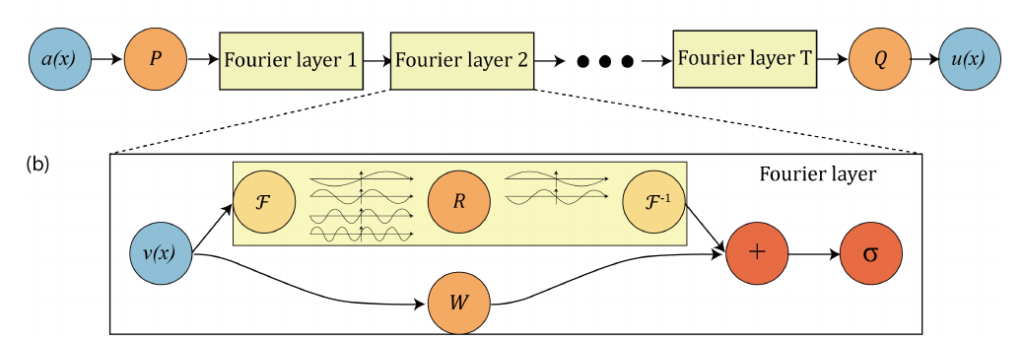

SFNO only replaced the Fourier operations to be spherical convolution
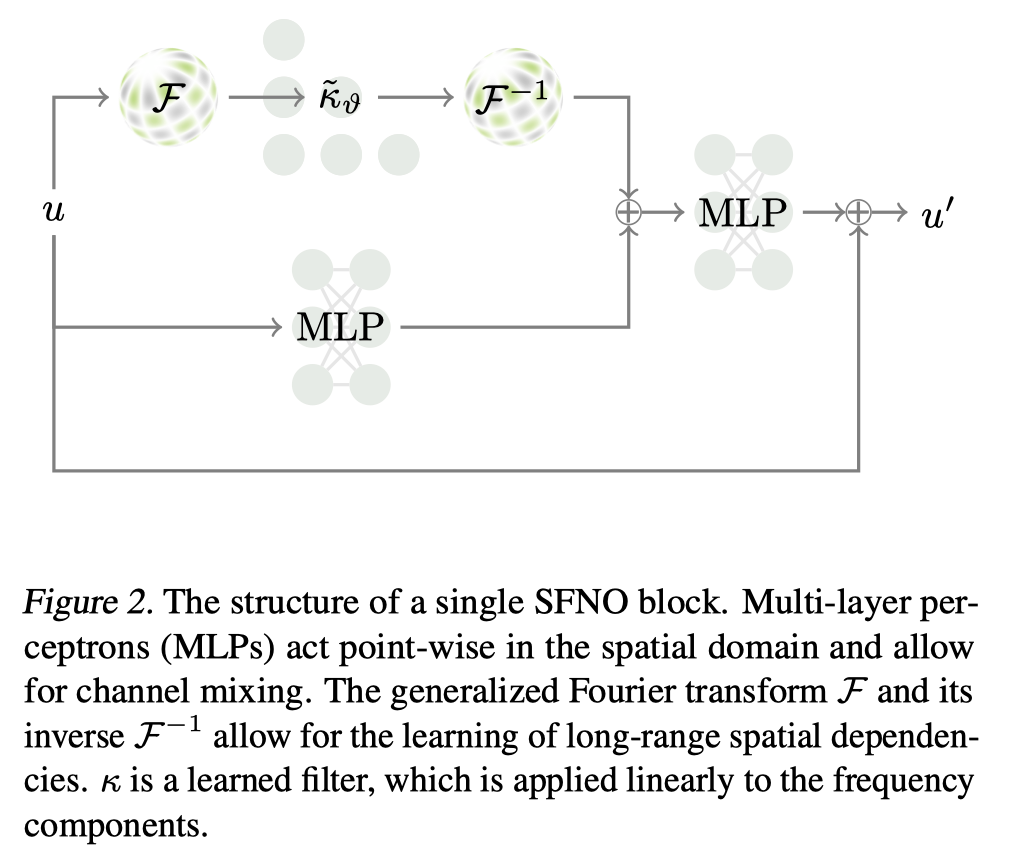

In [ ]:

# Activity 2 setup: official neuraloperator stack for spherical SWE.
# torch-harmonics is needed for the spherical harmonic components.

%pip -q install neuraloperator torch-harmonics matplotlib

In [ ]:
# @title load packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

from neuralop.models import SFNO, FNO
from neuralop import Trainer, LpLoss
from neuralop.training import AdamW
from neuralop.data.datasets import load_spherical_swe
from neuralop.data.datasets.spherical_swe import SphericalSWEDataset
from neuralop.utils import count_model_params

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device =', device)


In [ ]:
# Lecture configuration: keep the official data-generation workflow, but make the models deeper
# and train a bit longer than the smallest official demo.
SWE_TRAIN_RESOLUTION = (32, 64)
SWE_TEST_RESOLUTIONS = [(32, 64), (64, 128)]
SWE_N_TRAIN = 200
SWE_N_TESTS = [40, 40]
SWE_BATCH_SIZE = 32
SWE_TEST_BATCH_SIZES = [40, 40]
SWE_N_LAYERS = 4
SWE_N_EPOCHS = 100

train_loader, test_loaders = load_spherical_swe(
    n_train=SWE_N_TRAIN,
    batch_size=SWE_BATCH_SIZE,
    train_resolution=SWE_TRAIN_RESOLUTION,
    test_resolutions=SWE_TEST_RESOLUTIONS,
    n_tests=SWE_N_TESTS,
    test_batch_sizes=SWE_TEST_BATCH_SIZES,
)

print('Available test resolutions:', list(test_loaders.keys()))


In [ ]:
# @title data size prep
sample_low = test_loaders[(32, 64)].dataset[0]
print(type(sample_low))
print(sample_low.keys())
print('x shape:', tuple(sample_low['x'].shape))
print('y shape:', tuple(sample_low['y'].shape))

dataset_rows = []
dataset_rows.append({
    'split': 'train',
    'resolution': f'{train_loader.dataset.nlat}x{train_loader.dataset.nlon}',
    'channels': sample_low['x'].shape[0],
    'learned state': '$(\phi,\zeta,\delta)$',
    'target lead time [s]': 3600,
    'target lead time [h]': 3600 / 3600,
    'internal solver dt [s]': float(train_loader.dataset.solver.dt),
    'solver substeps per pair': int(train_loader.dataset.nsteps),
    'normalization': bool(train_loader.dataset.normalize),
})
for resolution in SWE_TEST_RESOLUTIONS:
    ds = test_loaders[resolution].dataset
    dataset_rows.append({
        'split': 'test',
        'resolution': f'{ds.nlat}x{ds.nlon}',
        'channels': sample_low['x'].shape[0],
        'learned state': '$(\phi,\zeta,\delta)$',
        'target lead time [s]': 3600,
        'target lead time [h]': 3600 / 3600,
        'internal solver dt [s]': float(ds.solver.dt),
        'solver substeps per pair': int(ds.nsteps),
        'normalization': bool(ds.normalize),
    })
display(pd.DataFrame(dataset_rows))


In [ ]:
# @title help functions
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

SWE_CHANNEL_INFO = [
    {
        'name': r'geopotential $\phi = g h$',
        'short': r'$\phi$',
        'cmap': 'viridis',
        'symmetric': False,
        'cbar': r'$\phi$ [m$^2$/s$^2$]',
    },
    {
        'name': r'relative vorticity $\zeta$',
        'short': r'$\zeta$',
        'cmap': 'RdBu_r',
        'symmetric': True,
        'cbar': r'$\zeta$ [s$^{-1}$]',
    },
    {
        'name': r'divergence $\delta$',
        'short': r'$\delta$',
        'cmap': 'PuOr_r',
        'symmetric': True,
        'cbar': r'$\delta$ [s$^{-1}$]',
    },
]


def denormalize_swe_field(field_chw, dataset):
    mean = dataset.inp_mean.detach().cpu().numpy()
    std = np.sqrt(dataset.inp_var.detach().cpu().numpy())
    return field_chw * std + mean


def _lon_lat_arrays(dataset=None, field2d=None):
    if dataset is not None:
        lons = dataset.solver.lons.detach().cpu().numpy().reshape(-1)
        lats = dataset.solver.lats.detach().cpu().numpy().reshape(-1)
    else:
        assert field2d is not None
        nlat, nlon = field2d.shape
        lons = np.linspace(0.0, 2.0 * np.pi, nlon, endpoint=False)
        lats = np.linspace(-0.5 * np.pi, 0.5 * np.pi, nlat)
    return lons, lats


def _mollweide_coords(field2d, dataset=None):
    lons, lats = _lon_lat_arrays(dataset=dataset, field2d=field2d)
    shifted = np.roll(np.asarray(field2d), field2d.shape[-1] // 2, axis=-1)
    lon_wrapped = np.linspace(-np.pi, np.pi, field2d.shape[-1], endpoint=False)
    lat_grid, lon_grid = np.meshgrid(lats, lon_wrapped, indexing='ij')
    return shifted, lon_grid, lat_grid


def swe_plot_limits(field, channel):
    field = np.asarray(field)
    if SWE_CHANNEL_INFO[channel]['symmetric']:
        lim = np.nanmax(np.abs(field))
        return -lim, lim
    return np.nanmin(field), np.nanmax(field)


def _add_compact_colorbar(ax, im, label, projection='mollweide'):
    if projection == 'mollweide':
        # Put a short vertical colorbar just outside the right edge of each panel.
        # This avoids covering titles while keeping the gallery style compact.
        cax = inset_axes(
            ax,
            width="2.8%",
            height="90%",
            loc='center left',
            bbox_to_anchor=(1.03, 0.0, 1.0, 1.0),
            bbox_transform=ax.transAxes,
            borderpad=0.0,
        )
        cb = plt.colorbar(im, cax=cax, orientation='vertical')
    else:
        cb = plt.colorbar(im, ax=ax, shrink=0.92, pad=0.03)

    cb.set_label(label, fontsize=8, labelpad=3)
    cb.ax.tick_params(labelsize=7, length=2)
    return cb


def plot_swe_scalar(ax, field2d, channel, title, dataset=None, projection='mollweide', vmin=None, vmax=None):
    meta = SWE_CHANNEL_INFO[channel]
    field2d = np.asarray(field2d)

    if projection == 'latlon':
        lons, lats = _lon_lat_arrays(dataset=dataset, field2d=field2d)
        lon_deg = np.rad2deg(lons)
        lat_deg = np.rad2deg(lats)
        Lon, Lat = np.meshgrid(lon_deg, lat_deg)
        im = ax.pcolormesh(
            Lon, Lat, field2d,
            shading='auto',
            cmap=meta['cmap'],
            vmin=vmin, vmax=vmax,
        )
        ax.set_xlabel('longitude [deg]')
        ax.set_ylabel('latitude [deg]')

    elif projection == 'mollweide':
        shifted, Lon, Lat = _mollweide_coords(field2d, dataset=dataset)
        im = ax.pcolormesh(
            Lon, Lat, shifted,
            shading='auto',
            cmap=meta['cmap'],
            vmin=vmin, vmax=vmax,
        )
        ax.grid(True, alpha=0.25, linewidth=0.5)
        ax.set_xticklabels([])
        ax.set_yticklabels([])

    else:
        raise ValueError(f'Unknown projection: {projection}')

    ax.set_title(title, fontsize=10, pad=9)
    _add_compact_colorbar(ax, im, meta['cbar'], projection=projection)
    return im


def show_swe_channels(sample, dataset=None, title_prefix='sample', projection='mollweide'):
    x = sample['x'].detach().cpu().numpy()
    y = sample['y'].detach().cpu().numpy()

    if dataset is not None and getattr(dataset, 'normalize', False):
        x = denormalize_swe_field(x, dataset)
        y = denormalize_swe_field(y, dataset)
        state_label = 'de-normalized solver-state fields'
        delta_t = float(dataset.nsteps * dataset.solver.dt)
    else:
        state_label = 'solver-state fields'
        delta_t = float(getattr(dataset.solver, 'dt', 3600.0) * getattr(dataset, 'nsteps', 1)) if dataset is not None else 3600.0

    hours = delta_t / 3600.0
    subplot_kw = {'projection': 'mollweide'} if projection == 'mollweide' else {}

    # Slightly wider figure and manual spacing so the right-side colorbars have room.
    fig, axes = plt.subplots(2, 3, figsize=(16.5, 7.2), subplot_kw=subplot_kw)
    axes = np.asarray(axes)

    for c, meta in enumerate(SWE_CHANNEL_INFO):
        vmin = min(np.nanmin(x[c]), np.nanmin(y[c]))
        vmax = max(np.nanmax(x[c]), np.nanmax(y[c]))
        if meta['symmetric']:
            lim = max(abs(vmin), abs(vmax))
            vmin, vmax = -lim, lim

        plot_swe_scalar(
            axes[0, c],
            x[c],
            c,
            rf'{title_prefix} input $q_t$: {meta["name"]}',
            dataset=dataset,
            projection=projection,
            vmin=vmin,
            vmax=vmax,
        )
        plot_swe_scalar(
            axes[1, c],
            y[c],
            c,
            rf'{title_prefix} target $q_{{t+\Delta t}}$: {meta["name"]}' + '\n' + rf'($\Delta t$ = {hours:g} h)',
            dataset=dataset,
            projection=projection,
            vmin=vmin,
            vmax=vmax,
        )

    fig.suptitle(f'Spherical SWE sample in {state_label}', y=0.97, fontsize=17)

    # Leave extra horizontal room between panels and a little more top margin.
    fig.subplots_adjust(
        left=0.04,
        right=0.97,
        bottom=0.06,
        top=0.88,
        wspace=0.30,
        hspace=0.28,
    )

    plt.show()

### How this SWE dataset is generated, and what the channels really mean

`load_spherical_swe(...)` does **not** read a static tensor file from disk. Instead, in the current `neuraloperator` implementation it builds samples **on the fly** by instantiating `torch_harmonics.examples.ShallowWaterSolver` and then:

1. drawing an initial condition such as a **random** state or a **Galewsky** jet,
2. advancing the spectral SWE solver for the required number of internal substeps,
3. converting the solver state from spectral space back to grid space, and
4. returning a one-step supervised pair `{"x": inp, "y": tar}`.

The default physical target interval is

$$
\Delta t = 3600\ \mathrm{s} = 1\ \mathrm{hour},
$$

while the solver itself may use smaller internal substeps for stability. So the machine-learning target is still a **one-hour operator step** even if the numerical solver internally takes multiple smaller steps.

Most importantly, the channels here are **not** $(u,v,h)$. The learned state is

$$
q = (\phi,\zeta,\delta),
\qquad \phi = gh,
$$

so the channels are:

- channel 0: geopotential $\phi$,
- channel 1: relative vorticity $\zeta$,
- channel 2: divergence $\delta$.

All main plots below therefore use those solver-state labels explicitly. If we wanted primitive variables like $(u,v,h)$, we would first need to invert the solver state back to them.


In [ ]:
demo_random = SphericalSWEDataset(dims=(32, 64), num_examples=1, normalize=False, device=device)
show_swe_channels(
    demo_random[0],
    dataset=demo_random,
    title_prefix='Generated random-IC one-step pair\n',
    projection='mollweide',
)

try:
    demo_galewsky = SphericalSWEDataset(
        dims=(32, 64),
        initial_condition='galewsky',
        num_examples=1,
        normalize=False,
        device=device,
    )
    galewsky_sample = demo_galewsky[0]
    if torch.isfinite(galewsky_sample['x']).all() and torch.isfinite(galewsky_sample['y']).all():
        show_swe_channels(
            galewsky_sample,
            dataset=demo_galewsky,
            title_prefix='Generated Galewsky one-step pair\n',
            projection='mollweide',
        )
    else:
        print('Galewsky sample contains non-finite values in this installed package version; skipping the gallery.')
except Exception as exc:
    print(f'Galewsky demo failed on this runtime ({exc}); random-IC demo above is still valid.')


In [ ]:
model = SFNO(
    n_modes=(16, 32),
    in_channels=3,
    out_channels=3,
    hidden_channels=64,
    domain_padding=[0.05, 0.05],
    n_layers=SWE_N_LAYERS,
).to(device)

print(model)
print('parameters =', count_model_params(model))


In [ ]:
optimizer = AdamW(model.parameters(), lr=5e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=SWE_N_EPOCHS)
l2loss = LpLoss(d=2, p=2, reduction='sum')

trainer = Trainer(
    model=model,
    n_epochs=SWE_N_EPOCHS,
    device=device,
    wandb_log=False,
    eval_interval=5,
    use_distributed=False,
    verbose=True,
)


In [ ]:

trainer.train(
    train_loader=train_loader,
    test_loaders=test_loaders,
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=l2loss,
    eval_losses={'l2': l2loss},
)

The training cell above keeps the **official data-generation workflow** and optimizer family from the package example, but uses a **deeper 4-layer SFNO** and a somewhat longer run than the smallest gallery demo.

Because `SphericalSWEDataset` is generated on the fly, we cache one fixed evaluation sample at each resolution for later comparisons. That cache is only for **consistent evaluation**; we do not need an extra stand-alone “cached example” figure.

From this point onward, Activity 2 plots are labeled strictly in terms of the learned solver-state variables

$$
q=(\phi,\zeta,\delta),
$$

not as raw $(u,v,h)$, and the main 2D field plots use a **Mollweide projection** so the spherical geometry remains visible.


In [ ]:
# Cache one fixed evaluation sample at each resolution.
# This matters because SphericalSWEDataset generates a new sample on each __getitem__ call.

eval_bundles = {}
for resolution in SWE_TEST_RESOLUTIONS:
    dataset = test_loaders[resolution].dataset
    sample = dataset[0]
    eval_bundles[resolution] = {
        'dataset': dataset,
        'sample': sample,
    }


In [ ]:
@torch.no_grad()
def predict_sample(model, sample):
    model.eval()
    x = sample['x'].unsqueeze(0).to(device)
    yhat = model(x).squeeze(0).detach().cpu().numpy()
    return yhat

def build_eval_state_dict(model, bundle):
    dataset = bundle['dataset']
    sample = bundle['sample']

    x_norm = sample['x'].detach().cpu().numpy()
    y_norm = sample['y'].detach().cpu().numpy()
    pred_norm = predict_sample(model, sample)

    x_phys = denormalize_swe_field(x_norm, dataset)
    y_phys = denormalize_swe_field(y_norm, dataset)
    pred_phys = denormalize_swe_field(pred_norm, dataset)

    return {
        'input': x_phys,
        'truth': y_phys,
        'pred': pred_phys,
    }

low_eval = build_eval_state_dict(model, eval_bundles[(32, 64)])
high_eval = build_eval_state_dict(model, eval_bundles[(64, 128)])

input_low, true_low, pred_low = low_eval['input'], low_eval['truth'], low_eval['pred']
input_high, true_high, pred_high = high_eval['input'], high_eval['truth'], high_eval['pred']


In [ ]:
def plot_same_and_super_resolution(true_low, pred_low, true_high, pred_high, channel=1, projection='mollweide'):
    channel_name = SWE_CHANNEL_INFO[channel]['name']
    subplot_kw = {'projection': 'mollweide'} if projection == 'mollweide' else {}
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), subplot_kw=subplot_kw)

    vmin = min(np.nanmin(true_low[channel]), np.nanmin(pred_low[channel]))
    vmax = max(np.nanmax(true_low[channel]), np.nanmax(pred_low[channel]))
    if SWE_CHANNEL_INFO[channel]['symmetric']:
        lim = max(abs(vmin), abs(vmax))
        vmin, vmax = -lim, lim
    plot_swe_scalar(
        axes[0, 0], true_low[channel], channel,
        f'Truth (32x64)\n{channel_name}',
        dataset=eval_bundles[(32, 64)]['dataset'], projection=projection, vmin=vmin, vmax=vmax
    )
    plot_swe_scalar(
        axes[0, 1], pred_low[channel], channel,
        f'SFNO (32x64)\n{channel_name}',
        dataset=eval_bundles[(32, 64)]['dataset'], projection=projection, vmin=vmin, vmax=vmax
    )
    # TODO: define what is the misfit (not absolute) for the low resolution case
    err_low = #????
    elow = np.nanmax(np.abs(err_low))
    plot_swe_scalar(
        axes[0, 2], err_low, channel,
        f'Error (32x64)\n{channel_name}',
        dataset=eval_bundles[(32, 64)]['dataset'], projection=projection, vmin=-elow, vmax=elow
    )

    vmin = min(np.nanmin(true_high[channel]), np.nanmin(pred_high[channel]))
    vmax = max(np.nanmax(true_high[channel]), np.nanmax(pred_high[channel]))
    if SWE_CHANNEL_INFO[channel]['symmetric']:
        lim = max(abs(vmin), abs(vmax))
        vmin, vmax = -lim, lim
    plot_swe_scalar(
        axes[1, 0], true_high[channel], channel,
        f'Truth (64x128)\n{channel_name}',
        dataset=eval_bundles[(64, 128)]['dataset'], projection=projection, vmin=vmin, vmax=vmax
    )
    plot_swe_scalar(
        axes[1, 1], pred_high[channel], channel,
        f'SFNO (64x128)\n{channel_name}',
        dataset=eval_bundles[(64, 128)]['dataset'], projection=projection, vmin=vmin, vmax=vmax
    )
    # TODO: define what is the misfit (not absolute) for the high resolution case
    err_high = #????
    ehigh = np.nanmax(np.abs(err_high))
    plot_swe_scalar(
        axes[1, 2], err_high, channel,
        f'Error (64x128)\n{channel_name}',
        dataset=eval_bundles[(64, 128)]['dataset'], projection=projection, vmin=-ehigh, vmax=ehigh
    )

    fig.suptitle('SFNO on spherical SWE: training grid vs zero-shot super-resolution', y=0.98, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])

plot_same_and_super_resolution(true_low, pred_low, true_high, pred_high, channel=1, projection='mollweide')


## Power-spectrum comparison

Neural operators often look good in physical space but still distort the energy distribution across scales. To make this visible, we compare **1D zonal power spectra** of truth and prediction.

Implementation choice here:

- take each 2D field
- compute an FFT along longitude
- average the power over latitude and over the 3 channels

This is not the only possible spectrum definition on the sphere, but it is a simple and interpretable teaching diagnostic.

In [ ]:
def zonal_power_spectrum(field_chw, channel=1):
    field = np.asarray(field_chw)[channel]
    field = field - field.mean(axis=-1, keepdims=True)
    ft = np.fft.rfft(field, axis=-1)
    power = np.abs(ft) ** 2
    power = power.mean(axis=0)
    k = np.arange(power.shape[0])
    return k, power

SPECTRUM_CHANNEL = 1
k_low_true, p_low_true = zonal_power_spectrum(true_low, channel=SPECTRUM_CHANNEL)
k_low_pred, p_low_pred = zonal_power_spectrum(pred_low, channel=SPECTRUM_CHANNEL)
k_high_true, p_high_true = zonal_power_spectrum(true_high, channel=SPECTRUM_CHANNEL)
k_high_pred, p_high_pred = zonal_power_spectrum(pred_high, channel=SPECTRUM_CHANNEL)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
spectrum_name = SWE_CHANNEL_INFO[SPECTRUM_CHANNEL]['name']

axes[0].plot(k_low_true[1:], p_low_true[1:], label='truth')
axes[0].plot(k_low_pred[1:], p_low_pred[1:], label='SFNO')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_title(f'Same-resolution zonal spectrum: {spectrum_name}')
axes[0].set_xlabel('zonal wavenumber')
axes[0].set_ylabel('power')
axes[0].legend()

#TODO: visualize the super-resolution power spectra
axes[1].plot(, label='truth')#????
axes[1].plot(, label='SFNO')#????
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title(f'Super-resolution zonal spectrum: {spectrum_name}')
axes[1].set_xlabel('zonal wavenumber')
axes[1].set_ylabel('power')
axes[1].legend()

plt.tight_layout()


In [ ]:
def rel_l2(a, b):
    return np.linalg.norm(a - b) / np.linalg.norm(b)

rows = []
for c, meta in enumerate(SWE_CHANNEL_INFO):
    rows.append({
        'channel': meta['name'],
        'rel_l2_32x64': rel_l2(pred_low[c], true_low[c]),
        'rel_l2_64x128': rel_l2(pred_high[c], true_high[c]),
    })
display(pd.DataFrame(rows))


### Compare SFNO with a plain FNO on the same spherical SWE data

This is intentionally a **geometry-mismatched baseline**. A standard FNO treats the latitude–longitude grid more like a planar regular grid, whereas SFNO is built for data on the sphere through spherical harmonics.

For a clean comparison, both models below use **4 layers** and the same one-step task

$$
(\phi_t,\zeta_t,\delta_t)\mapsto(\phi_{t+\Delta t},\zeta_{t+\Delta t},\delta_{t+\Delta t}).
$$

In this notebook the two models often perform **surprisingly similarly** at these moderate resolutions and short lead times. That is a good discussion point rather than a problem: if the task is relatively smooth, the forecast horizon is short, and the grid is not extremely fine, the geometry advantage of SFNO may not dominate yet. The comparison is still useful because it sets up the question of **when** spherical inductive bias becomes important.


In [ ]:

import pandas as pd


def plot_sfno_fno_comparison(true_low, sfno_low, fno_low, true_high, sfno_high, fno_high, channel=1, projection='mollweide'):
    channel_name = SWE_CHANNEL_INFO[channel]['name']
    subplot_kw = {'projection': 'mollweide'} if projection == 'mollweide' else {}
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), subplot_kw=subplot_kw)

    row_specs = [
        ((32, 64), true_low, sfno_low, fno_low),
        ((64, 128), true_high, sfno_high, fno_high),
    ]

    for row, (resolution, truth, sfno_pred, fno_pred) in enumerate(row_specs):
        vmin = min(np.nanmin(truth[channel]), np.nanmin(sfno_pred[channel]), np.nanmin(fno_pred[channel]))
        vmax = max(np.nanmax(truth[channel]), np.nanmax(sfno_pred[channel]), np.nanmax(fno_pred[channel]))
        if SWE_CHANNEL_INFO[channel]['symmetric']:
            lim = max(abs(vmin), abs(vmax))
            vmin, vmax = -lim, lim

        plot_swe_scalar(
            axes[row, 0], truth[channel], channel,
            f'Truth {resolution}\n{channel_name}',
            dataset=eval_bundles[resolution]['dataset'], projection=projection, vmin=vmin, vmax=vmax
        )
        plot_swe_scalar(
            axes[row, 1], sfno_pred[channel], channel,
            f'SFNO {resolution}\n{channel_name}',
            dataset=eval_bundles[resolution]['dataset'], projection=projection, vmin=vmin, vmax=vmax
        )
        plot_swe_scalar(
            axes[row, 2], fno_pred[channel], channel,
            f'FNO {resolution}\n{channel_name}',
            dataset=eval_bundles[resolution]['dataset'], projection=projection, vmin=vmin, vmax=vmax
        )

    fig.suptitle('SFNO versus FNO on spherical SWE', y=0.98, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.95])


fno_model = FNO(
    n_modes=(16, 32),
    in_channels=3,
    out_channels=3,
    hidden_channels=64,
    domain_padding=[0.05, 0.05],
    n_layers=SWE_N_LAYERS,
).to(device)

print(fno_model)
print('parameters =', count_model_params(fno_model))

fno_optimizer = AdamW(fno_model.parameters(), lr=5e-3, weight_decay=1e-4)
fno_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(fno_optimizer, T_max=SWE_N_EPOCHS)
fno_loss = LpLoss(d=2, p=2, reduction='sum')

fno_trainer = Trainer(
    model=fno_model,
    n_epochs=SWE_N_EPOCHS,
    device=device,
    wandb_log=False,
    eval_interval=5,
    use_distributed=False,
    verbose=True,
)

fno_trainer.train(
    train_loader=train_loader,
    test_loaders=test_loaders,
    optimizer=fno_optimizer,
    scheduler=fno_scheduler,
    regularizer=False,
    training_loss=fno_loss,
    eval_losses={'l2': fno_loss},
)

fno_low_eval = build_eval_state_dict(fno_model, eval_bundles[(32, 64)])
fno_high_eval = build_eval_state_dict(fno_model, eval_bundles[(64, 128)])
fno_pred_low = fno_low_eval['pred']
fno_pred_high = fno_high_eval['pred']

rows = []
for c, meta in enumerate(SWE_CHANNEL_INFO):
    rows.append({
        'channel': meta['name'],
        'SFNO rel_l2_32x64': rel_l2(pred_low[c], true_low[c]),
        'SFNO rel_l2_64x128': rel_l2(pred_high[c], true_high[c]),
        'FNO rel_l2_32x64': rel_l2(fno_pred_low[c], true_low[c]),
        'FNO rel_l2_64x128': rel_l2(fno_pred_high[c], true_high[c]),
    })
display(pd.DataFrame(rows))

plot_sfno_fno_comparison(
    true_low, pred_low, fno_pred_low,
    true_high, pred_high, fno_pred_high,
    channel=1, projection='mollweide'
)


### Autoregressive rollout and operator-stride experiment on many random-IC trajectories

For the stride experiment we now use:

- some long trajectories from **random initial conditions**,
- random training windows sampled from those trajectories,
- separate holdout trajectories for evaluation,
- a comparison between a **1 h operator** and a **3 h operator** (or 4, 6, 12...) over the same **24 h** forecast horizon.

This isolates the main scientific question:

- does applying a learned operator many small times accumulate more error,
- or is it harder to learn a larger physical jump directly,
- and how do those tradeoffs compare over the same forecast horizon?

Note that the numerical solver has to obey the limit of the CFL (Courant-Friedrichs-Lewy) number to be stable, i.e., information cannot travel more than one cell at each step; but neural operators can learn the mapping for much longer timesteps.


In [ ]:
# -----------------------------
# User-facing knobs
# -----------------------------
DIMS = (64, 128)
DT_SECONDS = 3600
MACH = 0.2

N_TRAIN_TRAJ = 10
N_TEST_TRAJ = 3
TOTAL_HOURS_LONG = 120      # each trajectory runs for 5 days
N_TRAIN_PAIRS = 1800
N_TEST_PAIRS = 360
BATCH_SIZE = 16

STRIDE_1H = 1
STRIDE_LONG = 3             # 2, 3, 4, 6, 8, 12, ...

# Forecast comparison over one 24 h window on an unseen holdout trajectory
EVAL_START_HOUR = 24
FORECAST_HOURS = 24
SNAPSHOT_HOURS = [6, 12, 18, 24]

# Choose which solver-state channel to visualize
# 0 = geopotential, 1 = relative vorticity, 2 = divergence
CHANNEL = 1


In [ ]:
# @title run random-IC autoregression
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# ============================================================
# Utilities
# ============================================================

@torch.no_grad()
def normalize_swe_state(state, mean, std):
    return (state - mean) / std

@torch.no_grad()
def denormalize_swe_state(state, mean, std):
    return state * std + mean

def rel_l2_np(pred, true):
    denom = np.linalg.norm(true.ravel())
    if denom < 1e-12:
        return np.nan
    return np.linalg.norm((pred - true).ravel()) / denom

def _clone_rng_state():
    state = {"cpu": torch.random.get_rng_state()}
    if torch.cuda.is_available():
        state["cuda"] = torch.cuda.get_rng_state_all()
    return state

def _restore_rng_state(state):
    torch.random.set_rng_state(state["cpu"])
    if torch.cuda.is_available() and "cuda" in state:
        torch.cuda.set_rng_state_all(state["cuda"])


# ============================================================
# Dataset built from many long trajectories + random windows
# ============================================================

class MultiTrajectoryPairDataset(Dataset):
    def __init__(self, bank, pair_specs, mean, var):
        """
        bank: tensor [n_traj, n_time, n_chan, n_lat, n_lon] in physical units
        pair_specs: list of tuples (traj_idx, start_idx, stride_steps)
        mean, var: tensors [n_chan, 1, 1]
        """
        self.bank = bank.float().cpu()
        self.pair_specs = pair_specs
        self.inp_mean = mean.float().cpu()
        self.inp_var = var.float().cpu().clamp_min(1e-12)
        self.inp_std = torch.sqrt(self.inp_var)

    def __len__(self):
        return len(self.pair_specs)

    def __getitem__(self, index):
        traj_idx, start_idx, stride_steps = self.pair_specs[index]
        x = self.bank[traj_idx, start_idx]
        y = self.bank[traj_idx, start_idx + stride_steps]
        return {
            "x": ((x - self.inp_mean) / self.inp_std).clone(),
            "y": ((y - self.inp_mean) / self.inp_std).clone(),
        }


def compute_bank_stats(bank):
    # bank shape [n_traj, n_time, c, h, w]
    mean = bank.mean(dim=(0, 1, 3, 4), keepdim=False).view(-1, 1, 1)
    var = bank.var(dim=(0, 1, 3, 4), unbiased=False, keepdim=False).view(-1, 1, 1)
    return mean.float().cpu(), var.float().cpu().clamp_min(1e-12)


def sample_pair_specs(n_traj, n_time, stride_steps, n_pairs, seed=0, start_min=0, start_max=None):
    rng = np.random.default_rng(seed)
    if start_max is None:
        start_max = n_time - 1 - stride_steps
    start_max = min(start_max, n_time - 1 - stride_steps)
    if start_max < start_min:
        raise ValueError(f"Invalid start range: [{start_min}, {start_max}]")

    traj_ids = rng.integers(0, n_traj, size=n_pairs)
    starts = rng.integers(start_min, start_max + 1, size=n_pairs)
    return [(int(traj_ids[i]), int(starts[i]), int(stride_steps)) for i in range(n_pairs)]


def build_pair_loaders_from_bank(
    train_bank,
    test_bank,
    stride_steps,
    n_train_pairs=1600,
    n_test_pairs=320,
    batch_size=16,
    seed=0,
    start_min=0,
    start_max=None,
):
    mean, var = compute_bank_stats(train_bank)

    train_specs = sample_pair_specs(
        n_traj=train_bank.shape[0],
        n_time=train_bank.shape[1],
        stride_steps=stride_steps,
        n_pairs=n_train_pairs,
        seed=seed,
        start_min=start_min,
        start_max=start_max,
    )
    test_specs = sample_pair_specs(
        n_traj=test_bank.shape[0],
        n_time=test_bank.shape[1],
        stride_steps=stride_steps,
        n_pairs=n_test_pairs,
        seed=seed + 1,
        start_min=start_min,
        start_max=start_max,
    )

    train_ds = MultiTrajectoryPairDataset(train_bank, train_specs, mean, var)
    test_ds = MultiTrajectoryPairDataset(test_bank, test_specs, mean, var)

    train_loader_local = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader_local = DataLoader(
        test_ds,
        batch_size=max(1, min(batch_size, len(test_ds))),
        shuffle=False,
    )

    dims_key = (train_bank.shape[-2], train_bank.shape[-1])
    test_loaders_local = {dims_key: test_loader_local}
    return train_loader_local, test_loaders_local, train_ds, test_ds


# ============================================================
# Build many seeded random-IC trajectories
# ============================================================

def build_seeded_random_trajectory_bank(
    dims=(64, 128),
    dt_seconds=3600,
    total_hours=120,
    seeds=range(10),
    mach=0.2,
):
    """
    Build a bank of long trajectories from multiple seeded random initial conditions.
    Returns:
        bank: [n_traj, total_hours+1, 3, nlat, nlon] in physical units
        ds_template: dataset object holding solver/grid metadata
    """
    ds_template = SphericalSWEDataset(
        dims=dims,
        dt=dt_seconds,
        initial_condition="random",
        num_examples=1,
        normalize=False,
        device=device,
    )
    solver = ds_template.solver

    trajectories = []
    base_rng_state = _clone_rng_state()

    for seed in seeds:
        torch.manual_seed(int(seed))
        state_spec = solver.random_initial_condition(mach=mach)

        states = []
        for step in range(total_hours + 1):
            states.append(solver.spec2grid(state_spec).detach().cpu())
            if step < total_hours:
                state_spec = solver.timestep(state_spec, ds_template.nsteps)

        trajectories.append(torch.stack(states, dim=0))

    _restore_rng_state(base_rng_state)

    bank = torch.stack(trajectories, dim=0)  # [n_traj, n_time, c, h, w]
    return bank, ds_template


# ============================================================
# Model training + autoregressive rollout
# ============================================================

@torch.no_grad()
def autoregressive_rollout(model, initial_state_phys, mean, std, n_rollout_steps):
    model.eval()
    current = normalize_swe_state(initial_state_phys, mean, std).unsqueeze(0).to(device)
    preds_phys = []
    for _ in range(n_rollout_steps):
        next_norm = model(current).squeeze(0).detach().cpu()
        next_phys = denormalize_swe_state(next_norm, mean, std)
        preds_phys.append(next_phys)
        current = next_norm.unsqueeze(0).to(device)
    return torch.stack(preds_phys, dim=0)


def train_swe_operator(train_loader_local, test_loaders_local, n_layers=4, n_epochs=100):
    local_model = SFNO(
        n_modes=(16, 32),
        in_channels=3,
        out_channels=3,
        hidden_channels=64,
        domain_padding=[0.05, 0.05],
        n_layers=n_layers,
    ).to(device)

    local_optimizer = AdamW(local_model.parameters(), lr=5e-3, weight_decay=1e-4)
    local_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(local_optimizer, T_max=n_epochs)
    local_loss = LpLoss(d=2, p=2, reduction="sum")

    local_trainer = Trainer(
        model=local_model,
        n_epochs=n_epochs,
        device=device,
        wandb_log=False,
        eval_interval=10,
        use_distributed=False,
        verbose=True,
    )

    local_trainer.train(
        train_loader=train_loader_local,
        test_loaders=test_loaders_local,
        optimizer=local_optimizer,
        scheduler=local_scheduler,
        regularizer=False,
        training_loss=local_loss,
        eval_losses={"l2": local_loss},
    )
    return local_model


# ============================================================
# Main experiment: random IC, 1 h vs configurable long stride
# ============================================================


assert FORECAST_HOURS % STRIDE_LONG == 0, "FORECAST_HOURS must be divisible by STRIDE_LONG"
assert all(hour % STRIDE_LONG == 0 for hour in SNAPSHOT_HOURS), "All SNAPSHOT_HOURS must be divisible by STRIDE_LONG"

# -----------------------------
# Build many long trajectories
# -----------------------------
train_seeds = list(range(1000, 1000 + N_TRAIN_TRAJ))
test_seeds = list(range(9000, 9000 + N_TEST_TRAJ))

train_bank, swe_template = build_seeded_random_trajectory_bank(
    dims=DIMS,
    dt_seconds=DT_SECONDS,
    total_hours=TOTAL_HOURS_LONG,
    seeds=train_seeds,
    mach=MACH,
)
test_bank, _ = build_seeded_random_trajectory_bank(
    dims=DIMS,
    dt_seconds=DT_SECONDS,
    total_hours=TOTAL_HOURS_LONG,
    seeds=test_seeds,
    mach=MACH,
)

print(f"train_bank shape: {tuple(train_bank.shape)}")
print(f"test_bank  shape: {tuple(test_bank.shape)}")
print(f"Train pairs per stride: {N_TRAIN_PAIRS}")
print(f"Test pairs  per stride: {N_TEST_PAIRS}")
print(f"Configured long stride: {STRIDE_LONG} h")

# -----------------------------
# Build random-window pair datasets
# -----------------------------
train_loader_1h, test_loaders_1h, train_ds_1h, test_ds_1h = build_pair_loaders_from_bank(
    train_bank=train_bank,
    test_bank=test_bank,
    stride_steps=STRIDE_1H,
    n_train_pairs=N_TRAIN_PAIRS,
    n_test_pairs=N_TEST_PAIRS,
    batch_size=BATCH_SIZE,
    seed=11,
)

train_loader_long, test_loaders_long, train_ds_long, test_ds_long = build_pair_loaders_from_bank(
    train_bank=train_bank,
    test_bank=test_bank,
    stride_steps=STRIDE_LONG,
    n_train_pairs=N_TRAIN_PAIRS,
    n_test_pairs=N_TEST_PAIRS,
    batch_size=BATCH_SIZE,
    seed=29,
)

# -----------------------------
# Train 1 h and long-stride operators
# -----------------------------
model_1h = train_swe_operator(
    train_loader_1h,
    test_loaders_1h,
    n_layers=4,
    n_epochs=100,
)
model_long = train_swe_operator(
    train_loader_long,
    test_loaders_long,
    n_layers=4,
    n_epochs=120,
)

mean_1h = train_ds_1h.inp_mean
std_1h = torch.sqrt(train_ds_1h.inp_var)
mean_long = train_ds_long.inp_mean
std_long = torch.sqrt(train_ds_long.inp_var)

# -----------------------------
# Holdout 24 h forecast window
# -----------------------------
eval_traj = test_bank[0]  # unseen trajectory
assert EVAL_START_HOUR + FORECAST_HOURS <= eval_traj.shape[0] - 1

truth_window = eval_traj[EVAL_START_HOUR:EVAL_START_HOUR + FORECAST_HOURS + 1]
initial_state = truth_window[0]

pred_rollout_1h = autoregressive_rollout(
    model_1h,
    initial_state,
    mean_1h,
    std_1h,
    n_rollout_steps=FORECAST_HOURS,
)
pred_rollout_long = autoregressive_rollout(
    model_long,
    initial_state,
    mean_long,
    std_long,
    n_rollout_steps=FORECAST_HOURS // STRIDE_LONG,
)

# -----------------------------
# Error accumulation over 24 h
# -----------------------------
errors_1h = [
    rel_l2_np(pred_rollout_1h[k].numpy(), truth_window[k + 1].numpy())
    for k in range(FORECAST_HOURS)
]

common_hours = np.arange(STRIDE_LONG, FORECAST_HOURS + 1, STRIDE_LONG)
errors_1h_common = [errors_1h[h - 1] for h in common_hours]
errors_long = [
    rel_l2_np(pred_rollout_long[k].numpy(), truth_window[STRIDE_LONG * (k + 1)].numpy())
    for k in range(FORECAST_HOURS // STRIDE_LONG)
]

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(1, FORECAST_HOURS + 1), errors_1h, marker="o", ms=3.5, label="1 h operator rollout")
plt.plot(common_hours, errors_1h_common, "o", ms=6, label=f"1 h operator at common {STRIDE_LONG} h checkpoints")
plt.plot(common_hours, errors_long, marker="s", ms=6, label=f"{STRIDE_LONG} h operator rollout")
plt.yscale("log")
plt.xlabel("forecast lead time [hours]")
plt.ylabel("relative L2 error")
plt.title("Autoregressive error accumulation on a holdout random-IC trajectory")
plt.legend()
plt.tight_layout()

# -----------------------------
# Snapshot comparison
# -----------------------------
channel_name = SWE_CHANNEL_INFO[CHANNEL]["name"]

all_fields = []
for hour in SNAPSHOT_HOURS:
    all_fields.extend([
        truth_window[hour, CHANNEL].numpy(),
        pred_rollout_1h[hour - 1, CHANNEL].numpy(),
        pred_rollout_long[(hour // STRIDE_LONG) - 1, CHANNEL].numpy(),
    ])

vmin = min(np.nanmin(field) for field in all_fields)
vmax = max(np.nanmax(field) for field in all_fields)
if SWE_CHANNEL_INFO[CHANNEL]["symmetric"]:
    lim = max(abs(vmin), abs(vmax))
    vmin, vmax = -lim, lim

subplot_kw = {"projection": "mollweide"}
fig, axes = plt.subplots(
    3,
    len(SNAPSHOT_HOURS),
    figsize=(4.2 * len(SNAPSHOT_HOURS), 9.8),
    subplot_kw=subplot_kw,
)

for col, hour in enumerate(SNAPSHOT_HOURS):
    plot_swe_scalar(
        axes[0, col],
        truth_window[hour, CHANNEL].numpy(),
        CHANNEL,
        rf"Truth at +{hour} h" + "\n" + rf"{channel_name}",
        dataset=swe_template,
        projection="mollweide",
        vmin=vmin,
        vmax=vmax,
    )
    plot_swe_scalar(
        axes[1, col],
        pred_rollout_1h[hour - 1, CHANNEL].numpy(),
        CHANNEL,
        rf"1 h operator forecast at +{hour} h",
        dataset=swe_template,
        projection="mollweide",
        vmin=vmin,
        vmax=vmax,
    )
    plot_swe_scalar(
        axes[2, col],
        pred_rollout_long[(hour // STRIDE_LONG) - 1, CHANNEL].numpy(),
        CHANNEL,
        rf"{STRIDE_LONG} h operator forecast at +{hour} h",
        dataset=swe_template,
        projection="mollweide",
        vmin=vmin,
        vmax=vmax,
    )

fig.suptitle(
    "Holdout 24 h forecast window on an unseen random-IC trajectory",
    y=0.995,
    fontsize=16,
)
plt.tight_layout()

# -----------------------------
# Summary table at common checkpoints
# -----------------------------
comparison_rows = []
for hour in SNAPSHOT_HOURS:
    comparison_rows.append({
        "lead time [h]": hour,
        "1 h operator rel_l2": rel_l2_np(pred_rollout_1h[hour - 1].numpy(), truth_window[hour].numpy()),
        f"{STRIDE_LONG} h operator rel_l2": rel_l2_np(pred_rollout_long[(hour // STRIDE_LONG) - 1].numpy(), truth_window[hour].numpy()),
        "1 h operator applications": hour,
        f"{STRIDE_LONG} h operator applications": hour // STRIDE_LONG,
    })

display(pd.DataFrame(comparison_rows))

## Optional task — repeat the stride experiment with Galewsky initial conditions

In the main experiment above, we trained one-step operators using many **random initial-condition** trajectories.  
Here we repeat the same workflow using the classic **Galewsky jet** initial condition.

This is a useful comparison because the Galewsky problem produces a more structured, dynamically organized flow than random initial conditions. It is therefore a good test of how model behavior changes when the training distribution is dominated by one physically meaningful jet-instability scenario rather than a broad random ensemble.

In [ ]:
# -----------------------------
# User-facing knobs for optional task
# -----------------------------
GAL_TOTAL_HOURS_LONG = 144

# Use disjoint time offsets so train/test come from different dynamical phases
GAL_TRAIN_OFFSETS = [0, 12, 24, 36, 48, 60, 72, 84]
GAL_TEST_OFFSETS = [96, 108, 120]

GAL_N_TRAIN_PAIRS = 1800
GAL_N_TEST_PAIRS = 360
GAL_BATCH_SIZE = 16

GAL_STRIDE_1H = 1
GAL_STRIDE_LONG = 6  # Can be changed to 2, 3, 4, 6, 8, 12, ...

GAL_EVAL_START_HOUR = 24
GAL_FORECAST_HOURS = 24
GAL_SNAPSHOT_HOURS = [6, 12, 18, 24]

In [ ]:
# @title run Galewsky-IC autoregression

# ============================================================
# Optional task: Galewsky trajectory bank
# ============================================================

def build_galewsky_trajectory_bank_from_offsets(
    dims=(64, 128),
    dt_seconds=3600,
    total_hours=120,
    offsets_hours=(0, 12, 24, 36, 48),
):
    """
    Build a bank of trajectories from one long Galewsky run.

    Returns:
        bank: [n_traj, total_hours+1, 3, nlat, nlon] in physical units
        ds_template: dataset object with solver/grid metadata
    """
    ds_template = SphericalSWEDataset(
        dims=dims,
        dt=dt_seconds,
        initial_condition="galewsky",
        num_examples=1,
        normalize=False,
        device=device,
    )
    solver = ds_template.solver

    if not hasattr(solver, "galewsky_initial_condition"):
        raise AttributeError(
            "This torch-harmonics / neuraloperator version does not expose "
            "`solver.galewsky_initial_condition()`."
        )

    max_offset = int(max(offsets_hours))
    total_steps = max_offset + total_hours

    state_spec = solver.galewsky_initial_condition()
    master_states = []

    for step in range(total_steps + 1):
        master_states.append(solver.spec2grid(state_spec).detach().cpu())
        if step < total_steps:
            state_spec = solver.timestep(state_spec, ds_template.nsteps)

    master = torch.stack(master_states, dim=0)  # [time, c, h, w]

    bank = torch.stack(
        [master[offset:offset + total_hours + 1].clone() for offset in offsets_hours],
        dim=0,
    )
    return bank, ds_template




assert GAL_FORECAST_HOURS % GAL_STRIDE_LONG == 0, "GAL_FORECAST_HOURS must be divisible by GAL_STRIDE_LONG"
assert all(hour % GAL_STRIDE_LONG == 0 for hour in GAL_SNAPSHOT_HOURS), "All GAL_SNAPSHOT_HOURS must be divisible by GAL_STRIDE_LONG"

# -----------------------------
# Build Galewsky banks
# -----------------------------
gal_train_bank, gal_template = build_galewsky_trajectory_bank_from_offsets(
    dims=DIMS,
    dt_seconds=DT_SECONDS,
    total_hours=GAL_TOTAL_HOURS_LONG,
    offsets_hours=GAL_TRAIN_OFFSETS,
)
gal_test_bank, _ = build_galewsky_trajectory_bank_from_offsets(
    dims=DIMS,
    dt_seconds=DT_SECONDS,
    total_hours=GAL_TOTAL_HOURS_LONG,
    offsets_hours=GAL_TEST_OFFSETS,
)

print(f"gal_train_bank shape: {tuple(gal_train_bank.shape)}")
print(f"gal_test_bank  shape: {tuple(gal_test_bank.shape)}")
print(f"Configured long stride: {GAL_STRIDE_LONG} h")

# -----------------------------
# Build pair datasets
# -----------------------------
gal_train_loader_1h, gal_test_loaders_1h, gal_train_ds_1h, gal_test_ds_1h = build_pair_loaders_from_bank(
    train_bank=gal_train_bank,
    test_bank=gal_test_bank,
    stride_steps=GAL_STRIDE_1H,
    n_train_pairs=GAL_N_TRAIN_PAIRS,
    n_test_pairs=GAL_N_TEST_PAIRS,
    batch_size=GAL_BATCH_SIZE,
    seed=111,
)

gal_train_loader_long, gal_test_loaders_long, gal_train_ds_long, gal_test_ds_long = build_pair_loaders_from_bank(
    train_bank=gal_train_bank,
    test_bank=gal_test_bank,
    stride_steps=GAL_STRIDE_LONG,
    n_train_pairs=GAL_N_TRAIN_PAIRS,
    n_test_pairs=GAL_N_TEST_PAIRS,
    batch_size=GAL_BATCH_SIZE,
    seed=129,
)

# -----------------------------
# Train 1 h and long-stride operators
# -----------------------------
gal_model_1h = train_swe_operator(
    gal_train_loader_1h,
    gal_test_loaders_1h,
    n_layers=4,
    n_epochs=100,
)
gal_model_long = train_swe_operator(
    gal_train_loader_long,
    gal_test_loaders_long,
    n_layers=4,
    n_epochs=120,
)

gal_mean_1h = gal_train_ds_1h.inp_mean
gal_std_1h = torch.sqrt(gal_train_ds_1h.inp_var)
gal_mean_long = gal_train_ds_long.inp_mean
gal_std_long = torch.sqrt(gal_train_ds_long.inp_var)

# -----------------------------
# Holdout forecast window
# -----------------------------
gal_eval_traj = gal_test_bank[0]
assert GAL_EVAL_START_HOUR + GAL_FORECAST_HOURS <= gal_eval_traj.shape[0] - 1

gal_truth_window = gal_eval_traj[GAL_EVAL_START_HOUR:GAL_EVAL_START_HOUR + GAL_FORECAST_HOURS + 1]
gal_initial_state = gal_truth_window[0]

gal_pred_rollout_1h = autoregressive_rollout(
    gal_model_1h,
    gal_initial_state,
    gal_mean_1h,
    gal_std_1h,
    n_rollout_steps=GAL_FORECAST_HOURS,
)
gal_pred_rollout_long = autoregressive_rollout(
    gal_model_long,
    gal_initial_state,
    gal_mean_long,
    gal_std_long,
    n_rollout_steps=GAL_FORECAST_HOURS // GAL_STRIDE_LONG,
)

# -----------------------------
# Error accumulation
# -----------------------------
gal_errors_1h = [
    rel_l2_np(gal_pred_rollout_1h[k].numpy(), gal_truth_window[k + 1].numpy())
    for k in range(GAL_FORECAST_HOURS)
]

gal_common_hours = np.arange(GAL_STRIDE_LONG, GAL_FORECAST_HOURS + 1, GAL_STRIDE_LONG)
gal_errors_1h_common = [gal_errors_1h[h - 1] for h in gal_common_hours]
gal_errors_long = [
    rel_l2_np(gal_pred_rollout_long[k].numpy(), gal_truth_window[GAL_STRIDE_LONG * (k + 1)].numpy())
    for k in range(GAL_FORECAST_HOURS // GAL_STRIDE_LONG)
]

plt.figure(figsize=(8, 4.5))
plt.plot(np.arange(1, GAL_FORECAST_HOURS + 1), gal_errors_1h, marker="o", ms=3.5, label="1 h operator rollout")
plt.plot(
    gal_common_hours,
    gal_errors_1h_common,
    "o",
    ms=6,
    label=f"1 h operator at common {GAL_STRIDE_LONG} h checkpoints",
)
plt.plot(gal_common_hours, gal_errors_long, marker="s", ms=6, label=f"{GAL_STRIDE_LONG} h operator rollout")
plt.yscale("log")
plt.xlabel("forecast lead time [hours]")
plt.ylabel("relative L2 error")
plt.title("Galewsky optional task: autoregressive error accumulation")
plt.legend()
plt.tight_layout()

# -----------------------------
# Snapshot comparison
# -----------------------------
gal_channel_name = SWE_CHANNEL_INFO[CHANNEL]["name"]

gal_all_fields = []
for hour in GAL_SNAPSHOT_HOURS:
    gal_all_fields.extend([
        gal_truth_window[hour, CHANNEL].numpy(),
        gal_pred_rollout_1h[hour - 1, CHANNEL].numpy(),
        gal_pred_rollout_long[(hour // GAL_STRIDE_LONG) - 1, CHANNEL].numpy(),
    ])

gal_vmin = min(np.nanmin(field) for field in gal_all_fields)
gal_vmax = max(np.nanmax(field) for field in gal_all_fields)
if SWE_CHANNEL_INFO[CHANNEL]["symmetric"]:
    gal_lim = max(abs(gal_vmin), abs(gal_vmax))
    gal_vmin, gal_vmax = -gal_lim, gal_lim

subplot_kw = {"projection": "mollweide"}
fig, axes = plt.subplots(
    3,
    len(GAL_SNAPSHOT_HOURS),
    figsize=(4.2 * len(GAL_SNAPSHOT_HOURS), 9.8),
    subplot_kw=subplot_kw,
)

for col, hour in enumerate(GAL_SNAPSHOT_HOURS):
    plot_swe_scalar(
        axes[0, col],
        gal_truth_window[hour, CHANNEL].numpy(),
        CHANNEL,
        rf"Truth at +{hour} h" + "\n" + rf"{gal_channel_name}",
        dataset=gal_template,
        projection="mollweide",
        vmin=gal_vmin,
        vmax=gal_vmax,
    )
    plot_swe_scalar(
        axes[1, col],
        gal_pred_rollout_1h[hour - 1, CHANNEL].numpy(),
        CHANNEL,
        rf"1 h operator forecast at +{hour} h",
        dataset=gal_template,
        projection="mollweide",
        vmin=gal_vmin,
        vmax=gal_vmax,
    )
    plot_swe_scalar(
        axes[2, col],
        gal_pred_rollout_long[(hour // GAL_STRIDE_LONG) - 1, CHANNEL].numpy(),
        CHANNEL,
        rf"{GAL_STRIDE_LONG} h operator forecast at +{hour} h",
        dataset=gal_template,
        projection="mollweide",
        vmin=gal_vmin,
        vmax=gal_vmax,
    )

fig.suptitle(
    "Galewsky optional task: holdout forecast window",
    y=0.995,
    fontsize=16,
)
plt.tight_layout()

# -----------------------------
# Summary table
# -----------------------------
gal_rows = []
for hour in GAL_SNAPSHOT_HOURS:
    gal_rows.append({
        "lead time [h]": hour,
        "1 h operator rel_l2": rel_l2_np(gal_pred_rollout_1h[hour - 1].numpy(), gal_truth_window[hour].numpy()),
        f"{GAL_STRIDE_LONG} h operator rel_l2": rel_l2_np(
            gal_pred_rollout_long[(hour // GAL_STRIDE_LONG) - 1].numpy(),
            gal_truth_window[hour].numpy(),
        ),
        "1 h operator applications": hour,
        f"{GAL_STRIDE_LONG} h operator applications": hour // GAL_STRIDE_LONG,
    })

display(pd.DataFrame(gal_rows))

### Data-driven neural operators, and where PINO fits

This activity focuses on a **data-driven neural operator** workflow:  
we generate many examples with a numerical solver, then train a model to emulate that solver's one-step evolution map.

This is different from Activity 1, where the governing equations entered directly into the loss.

There is also an important hybrid class of methods called **physics-informed neural operators (PINOs)**, which combine operator learning with explicit PDE-based constraints. We do not implement PINO here, but it is useful to know that the space between purely data-driven and physics-constrained learning is not binary.

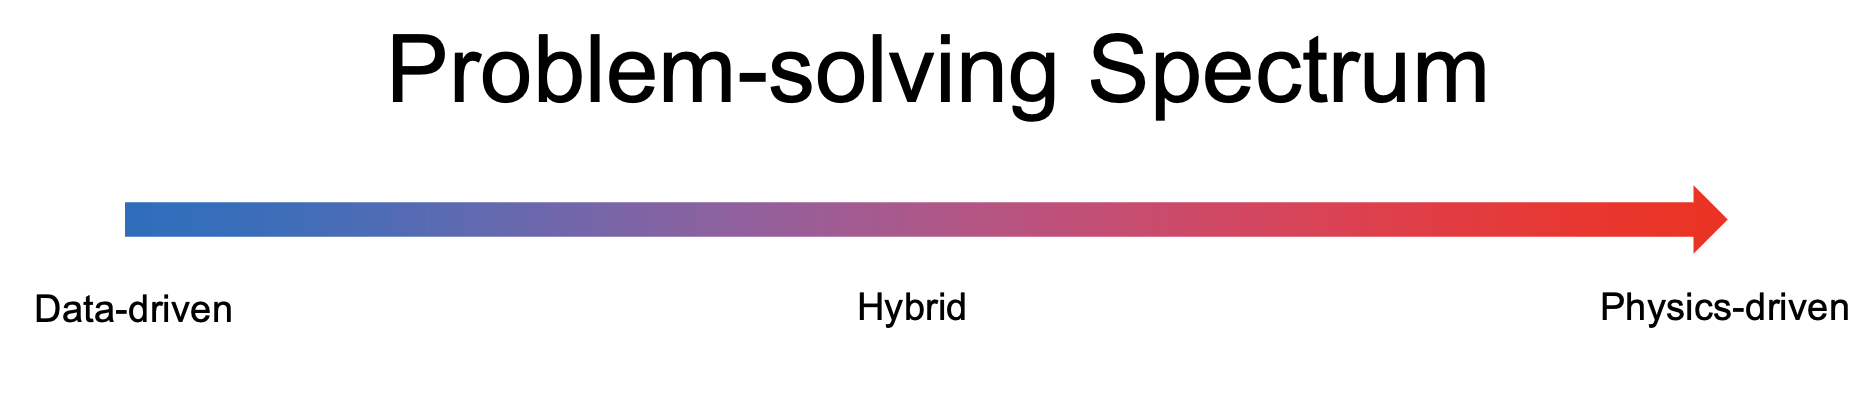

## Activity 2 takeaways

1. The `neuraloperator` spherical SWE dataset is generated **on the fly** through `torch_harmonics.examples.ShallowWaterSolver`.
2. Each supervised pair is a one-step time advance with default physical spacing $\Delta t=3600$ s, even though the solver may take smaller internal substeps.
3. The learned channels are **not** $(u,v,h)$; they are the solver-state variables
   $$
   q=(\phi,\zeta,\delta).
   $$
4. Zero-shot super-resolution is interesting because neural operators learn maps between infinite dimensional **functions**, not just between one fixed vector length and another.
5. In this notebook, **FNO** and **SFNO** can look fairly similar at moderate resolution and short one-step horizons. A useful discussion prompt is why the geometry-aware advantage of SFNO may only become obvious on harder tasks.
6. Autoregressive rollouts test something different from one-step prediction: small errors can accumulate, and the number of operator applications matters.
7. Comparing **1 h** and **3 h** learned operators over the same **24 h** horizon is a simple way to think about the tradeoff between **single-step difficulty** and **error accumulation**.


---

# Discussion prompts and student checklist


### Discussion

- Why might FNO and SFNO perform similarly on this notebook's one-step task even though SFNO is more geometry-aware? Read the SFNO paper to see under what cases SFNO starts to exhibit better performance
- Why can a model look strong at one step but degrade during long autoregressive rollout?
- Over a fixed 24 h horizon, what are the pros and cons of many 1 h applications versus fewer 3 h applications?

### Checklist

- [ ] I can state what the three learned SWE channels are.
- [ ] I can explain what zero-shot super-resolution means in this context.
- [ ] I can interpret the difference between one-step error and rollout error.


# Going Further
- increase the number of epochs and size of tranining data, can we improve the prediction in the power spectra space?
- increase/drecrease the resolution and/or change the number of Fourier/Spherical convolution layers, see how the problem complexities and model capacity impact the performance
- check to see Fourcastnet, in different generations (3 versions so far) how they deal with the different stride (timesteps), as well as geometry-related considerations
- Why there is relatively limited applications for Physics-informed version of FNO?
- FNO family has better mutli-scale "attention" compared with PINN or DeepONet, but still suffers from low-frequency bias. Compile and understand what attempts have been made and why they may or may not work

# References and source links

## Activity 1

- Wang, Y. and Lai, C.-Y. (2025), **DIFFICE-jax: Differentiable neural-network solver for data assimilation of ice shelves in JAX**, JOSS, 10(109), 7254. DOI: <https://doi.org/10.21105/joss.07254>
- DIFFICE_jax repository: <https://github.com/YaoGroup/DIFFICE_jax>
- Isotropic formulation in the docs: <https://github.com/YaoGroup/DIFFICE_jax/blob/main/docs/source/Isotropic.md>
- Data-format docs: <https://github.com/YaoGroup/DIFFICE_jax/blob/main/docs/source/Data.md>
- Data-processing docs: <https://diffice-jax.readthedocs.io/en/latest/code_data.html>
- Model / loss docs: <https://diffice-jax.readthedocs.io/en/latest/code_models.html>
- Optimizer docs: <https://diffice-jax.readthedocs.io/en/latest/code_optimizer.html>
- Official real-data colab notebook: <https://github.com/YaoGroup/DIFFICE_jax/blob/main/examples/colab/train_pinns_iso.ipynb>
- Real-data example folder: <https://github.com/YaoGroup/DIFFICE_jax/tree/main/examples/real_data>
- Science paper: Wang et al. (2025), **Deep learning the flow law of Antarctic ice shelves**, Science, 387, 1219–1224. DOI: <https://doi.org/10.1126/science.adp3300>

## Activity 2

- NeuralOperator library: <https://github.com/neuraloperator/neuraloperator>
- Official SFNO SWE example: <https://neuraloperator.github.io/dev/auto_examples/models/plot_SFNO_swe.html>
- SFNO example source: <https://github.com/neuraloperator/neuraloperator/blob/main/examples/models/plot_SFNO_swe.py>
- SWE dataset source used by `load_spherical_swe`: <https://github.com/neuraloperator/neuraloperator/blob/main/neuralop/data/datasets/spherical_swe.py>
- `torch-harmonics` SWE solver used by the dataset (`ShallowWaterSolver`): <https://raw.githubusercontent.com/NVIDIA/torch-harmonics/main/torch_harmonics/examples/shallow_water_equations.py>
- `SFNO` API docs: <https://neuraloperator.github.io/dev/modules/generated/neuralop.models.SFNO.html>
- `FNO` API docs: <https://neuraloperator.github.io/dev/modules/generated/neuralop.models.FNO.html>
- Bonev et al. (2023), **Spherical Fourier Neural Operators: Learning Stable Dynamics on the Sphere**. PMLR 202:4474–4496. <https://proceedings.mlr.press/v202/bonev23a.html>
- Li et al. (2021), **Fourier Neural Operator for Parametric Partial Differential Equations**. ICLR. <https://arxiv.org/abs/2010.08895>
- Galewsky, Scott, and Polvani (2004), **An initial-value problem for testing numerical models of the global shallow-water equations**. Tellus A, 56(5), 429–440. <https://doi.org/10.1111/j.1600-0870.2004.00071.x>
